<div style="display:flex;align-items:center;justify-content:center;flex-direction:column;padding:18px 0;">
<h1 style="font-family: 'Segoe UI', Roboto, Arial; font-size:48px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">
LOGISTIC REGRESSION ASSIGNMENT
</h1>
<p style="margin:8px 0 0; color:#334155; font-size:16px;">A concise workbook covering how to build logistic regression models, evaluate their performance, and interpret their coefficients to derive meaningful insights.</p>
</div>

---

<div style="display:flex;gap:12px;flex-wrap:wrap;align-items:center;">
<span style="background:#eef2ff;color:#3730a3;padding:6px 10px;border-radius:8px;font-weight:600;">📘 Basics</span>
<span style="background:#ecfdf5;color:#065f46;padding:6px 10px;border-radius:8px;font-weight:600;">⚙️ Examples</span>
<span style="background:#fff7ed;color:#92400e;padding:6px 10px;border-radius:8px;font-weight:600;">🔁 Exercises</span>
</div>


<details><summary><strong>Notebook info</strong></summary>

- **Author:** Sandipan Roy
- **Assignment Date:** 2026-02-25
- **Assignment Given By:** Karkavel Raja
- **Sections:** Importing Libraries · Data Loading · Data Preprocessing & Transformation Operations · Exploratory Data Analysis (EDA) · Fine-tuning and Optimization · Model Building · Model Evaluation · Model Optimization and Insights

</details>

---



<div style="display:flex;align-items:center;justify-content:center;flex-direction:column;padding:18px 0;">
<h2 style="font-family: 'Segoe UI', Roboto, Arial; font-size:38px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">Problem Statement:</h2>

---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">The objective of this assignment is to apply Logistic Regression algorithms to analyze given datasets, extracting meaningful insights and predicting outcomes based on the learned logistic models. By exploring the datasets, students will learn how to build regression models, evaluate their performance, and interpret their coefficients to derive meaningful insights.</p>
</div>

---



<div style="display:flex;align-items:center;justify-content:center;flex-direction:column;padding:18px 0;">
<h2 style="font-family: 'Segoe UI', Roboto, Arial; font-size:38px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">Dataset for the Assignment:</h2>

---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">


-   [Dry Bean Dataset Classification | Kaggle](https://www.kaggle.com/datasets/nimapourmoradi/dry-bean-dataset-classification/data)
-   [Banking Dataset Classification | Kaggle](https://www.kaggle.com/datasets/rashmiranu/banking-dataset-classification/data)
-   [Car Acceptability Classification Dataset | Kaggle](https://www.kaggle.com/datasets/subhajeetdas/car-acceptability-classification-dataset/data)


</p>
</div>

---


<div style="display:flex;align-items:center;justify-content:center;flex-direction:column;padding:18px 0;">
<h2 style="font-family: 'Segoe UI', Roboto, Arial; font-size:38px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">Business Objective:</h2>

---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">

-   [Dry Bean Dataset Classification | Kaggle](https://www.kaggle.com/datasets/nimapourmoradi/dry-bean-dataset-classification/data) :- Classification of the type of dry beans.

Seven different types of dry beans were used in this research, taking into account the features such as form, shape, type, and structure by the market situation. A computer vision system was developed to distinguish seven different registered varieties of dry beans with similar features in order to obtain uniform seed classification. For the classification model, images of 13,611 grains of 7 different registered dry beans were taken with a high-resolution camera. Bean images obtained by computer vision system were subjected to segmentation and feature extraction stages, and a total of 16 features; 12 dimensions and 4 shape forms, were obtained from the grains.
</p>
</div>

---



<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">1. Setup and Data Preparation:</h3>


---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Install the required libraries if not present.</u></li>
</ul>
</p>

---


In [1]:
!pip install scikit-learn
!pip install statsmodels
!pip install -U imbalanced-learn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Import all the required libraries and orchastrate control over the behaviour and display settings of pandas.</u></li>
</ul>
</p>

---


In [2]:
# Importing warning to disable runtime warnings
import warnings
# Warnings will appear only once
warnings.filterwarnings("ignore")

#=================================================================================

# Importing Numpy Library and aliasing it's name as np
import numpy as np
# Importing Pandas Library and aliasing it's name as pd
import pandas as pd
# Importing the Pyplot Interface from within the Matplotlib Library and aliasing it as plt
import matplotlib.pyplot as plt
# The above line of code can also be written as-
#    from matplotlib import pyplot as plt

# Importing Seaborn Library and aliasing it's name as sns
import seaborn as sns

# Importing the Plotly Express Interface from within the Plotly Library and aliasing it as px
import plotly.express as px

from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, multilabel_confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, StratifiedKFold

#=================================================================================

# Importing the OLS (Ordinary Least Squares) method from the statsmodels
# library. The OLS method is used to fit a linear regression model to the data.
# The OLS method estimates the parameters of a linear regression model
# by minimizing the sum of squared residuals (the differences between
# observed and predicted values).
import statsmodels.api as sm
# Importing the anova_lm function from the statsmodels library to perform ANOVA (Analysis of Variance) tests
from statsmodels.stats.anova import anova_lm
# Importing the het_breuschpagan function from the statsmodels library
# to perform the Breusch-Pagan test for heteroscedasticity. The Breusch-Pagan
# test is used to determine whether the variance of the residuals from
# a regression model is constant (homoscedasticity) or varies with the
# level of the independent variable (heteroscedasticity).
from statsmodels.stats.diagnostic import het_breuschpagan
# Importing the durbin_watson and jarque_bera functions from the
# statsmodels library to perform the Durbin-Watson test for
# autocorrelation and the Jarque-Bera test for normality, respectively
from statsmodels.stats.stattools import durbin_watson, jarque_bera

# Importing the stats module from the scipy library to perform various 
# statistical tests and analyses. The stats module provides a wide range 
# of functions for statistical analysis, including tests for normality, 
# homogeneity of variances, and non-parametric tests. In this code, we 
# will be using the levene function to test for homogeneity of variances, 
# the f_oneway function to perform one-way ANOVA, and the kruskal 
# function to perform the Kruskal-Wallis H-test for non-parametric data. 
from scipy.stats import levene, f_oneway, kruskal, normaltest


# Importing the pickle module to save and load Python objects. The pickle module
# allows us to serialize and deserialize Python objects, which means we can
# save a Python object to a file and load it back later. This is useful for
# saving trained models, preprocessed data, or any other Python objects that
# we want to persist across sessions or share with others.
import pickle


# Importing the chi2 function from the scipy.stats library to perform
# the chi-squared test for independence. The chi-squared test is used to
# determine whether there is a significant association between two categorical
# variables. It tests the null hypothesis that the two variables are
# independent. If the p-value is less than a chosen significance level
# (e.g., 0.05), then the null hypothesis is rejected, indicating that
# there is a significant association between the two variables.
from scipy.stats import chi2
# Importing the inv function from the numpy.linalg library to compute the
# inverse of a matrix. The inv function is used to calculate the inverse
# of a square matrix, which is often needed in linear regression analysis
# to compute the coefficients of the regression model. The inverse of a
# matrix A is denoted as A^-1, and it satisfies the property that
# A * A^-1 = I, where I is the identity matrix. In the context of
# linear regression, the inv function can be used to compute the coefficients
# of the regression model using the formula: beta = (X^T * X)^-1 * X^T * y,
# where X is the matrix of independent variables, y is the vector of dependent
# variable values, and beta is the vector of regression coefficients.
from numpy.linalg import inv
#=================================================================================

# Unfolding hidden features if the cardinality is high
pd.set_option('display.max_columns', None)
# Unfolding the max feature width for better clearity
pd.set_option('display.max_colwidth', None)
# Unfolding hidden data points if the cardinality is high
pd.set_option('display.max_rows', None)
# Removing restriction over chained assignments operations
pd.set_option('mode.chained_assignment', None)
# To suppress scientific notation over exponential values
pd.set_option('display.float_format', lambda x: '%.5f' % x)

%matplotlib inline

---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Acquire data from datasource and bring it in-memory.</u></li>
</ul>
</p>

---


In [3]:
def acquire_data(url, sourceType="csv", verbose=False):
    """
    This function acquires data from the given URL and returns a DataFrame.

    Parameters:
    url (str): The URL from which to acquire the data.
    sourceType (str): The type of the data source (default is "csv").
    verbose (bool): If True, prints the shape of the DataFrame and its columns.

    Returns:
    pd.DataFrame: The acquired data as a DataFrame.
    """

    if sourceType.lower() != "csv":
        raise ValueError("Currently, only 'csv' source type is supported.")

    # Reading the CSV file from the provided URL
    df = pd.read_csv(url)

    # If verbose is True, print the shape of the DataFrame and its columns
    if verbose:
        print(f"DataFrame Shape: {df.shape}, i.e., {df.shape[0]} rows and {df.shape[1]} columns.")
        print(f"DataFrame Columns: {df.columns.tolist()}")

    return df

In [4]:
url = "https://raw.githubusercontent.com/Sandipan-Roy/sr/refs/heads/Dev/ML/Regression/Logistic_Regression/data/raw/Dry_Bean_Dataset.csv"

data = acquire_data(url, verbose=True)

DataFrame Shape: (13611, 17), i.e., 13611 rows and 17 columns.
DataFrame Columns: ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']


---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Analyze the aquired data and perform pre-profiling.</u></li>
</ul>
</p>

---


In [5]:
def analyze_data(df):
    """
    This function performs basic analysis on the given DataFrame and prints the results.

    Parameters:
    df (pd.DataFrame): The DataFrame to analyze.

    Returns:
    __dict__: A dictionary containing the results of the numerical columns and categorical columns list.
    """

    # Displaying the first 5 rows of the DataFrame
    print("First 5 rows of the DataFrame:")
    print(df.head())

    # Displaying the last 5 rows of the DataFrame
    print("\nLast 5 rows of the DataFrame:")
    print(df.tail())

    # Displaying the shape of the DataFrame
    print(f"\nShape of the DataFrame: {df.shape}")

    # Displaying the data types of each column
    print("\nData types of each column:")
    print(df.dtypes)

    #Displaying information about the DataFrame
    print("\nInformation about the DataFrame:")
    print(df.info())

    # Displaying the memory usage of the DataFrame
    print(f"\nMemory usage of the DataFrame: {(df.memory_usage(deep=True)).sum() / 1024:.2f} KB")  # Converting bytes to kilobytes
    print(((df.memory_usage(deep=True)) / 1024).round(2))  # Converting bytes to kilobytes

    # Listing numerical columns
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # Listing categorical columns
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    print("\nWe have {} numerical features: {}".format(len(numerical_cols), numerical_cols))
    print("We have {} categorical features: {}".format(len(categorical_cols), categorical_cols))

    print("\nNumber of duplicated rows: {} ({}% of total rows)".format(
                    df.duplicated().sum(),
                    round(df.duplicated().sum() / df.shape[0] * 100, 2)
                    ))

    if len(numerical_cols) > 0:
      # Displaying summary statistics for numerical columns
      print("\nSummary statistics for numerical columns:")
      print(df.describe())

    if len(categorical_cols) > 0:
      # Displaying summary statistics for categorical columns
      print("\nSummary statistics for categorical columns:")
      print(df.describe(include=['object']))


    # Returning the list of numerical and categorical columns
    return {
        "numerical_columns": numerical_cols if len(numerical_cols) > 0 else None,
        "categorical_columns": categorical_cols if len(categorical_cols) > 0 else None
    }


In [6]:
dictColumns = analyze_data(data)
numerical_columns = dictColumns["numerical_columns"]
categorical_columns = dictColumns["categorical_columns"]

First 5 rows of the DataFrame:
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395  610.29100        208.17812        173.88875       1.19719   
1  28734  638.01800        200.52480        182.73442       1.09736   
2  29380  624.11000        212.82613        175.93114       1.20971   
3  30008  645.88400        210.55800        182.51652       1.15364   
4  30140  620.13400        201.84788        190.27928       1.06080   

   Eccentricity  ConvexArea  EquivDiameter  Extent  Solidity  roundness  \
0       0.54981       28715      190.14110 0.76392   0.98886    0.95803   
1       0.41179       29172      191.27275 0.78397   0.98499    0.88703   
2       0.56273       29690      193.41090 0.77811   0.98956    0.94785   
3       0.49862       30724      195.46706 0.78268   0.97670    0.90394   
4       0.33368       30417      195.89650 0.77310   0.99089    0.98488   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0      0.91

---
<a name = Section4></a>
### Data Acquisition Observations
---
The dataset consists of seven different types of dry beans were used in this research, taking into account the features such as form, shape, type, and structure by the market situation.

| Records | Features | Dataset Size |
| :-- | :-- | :-- |
| 13611 | 17 | 1.8+ MB |


| ID | Feature Name | Description of the feature | Data Type |
| :-- | :--| :--| :--|
|01| ** Area **   | The area of a bean zone and the number of pixels within its boundaries.                                   | int64 |
|02| ** Perimeter **   | Bean circumference is defined as the length of its border.                                   | float64 |
|03| ** MajorAxisLength **   | The distance between the ends of the longest line that can be drawn from a bean.                                   | float64 |
|04| ** MinorAxisLength **   | The longest line that can be drawn from the bean while standing perpendicular to the main axis.                                   | float64 |
|05| ** AspectRation **   | Defines the relationship between L and l.                                   | float64 |
|06| ** Eccentricity **   | Eccentricity of the ellipse having the same moments as the region.                                   | int64 |
|07| ** ConvexArea **   | Number of pixels in the smallest convex polygon that can contain the area of a bean seed.                                   | float64 |
|08| ** EquivDiameter **   | The diameter of a circle having the same area as a bean seed area.                                   | float64 |
|09| ** Extent **   | The ratio of the pixels in the bounding box to the bean area.                                   | float64 |
|10| ** Solidity **   | Also known as convexity. The ratio of the pixels in the convex shell to those found in beans.                                   | float64 |
|11| ** roundness **   | Calculated with the following formula: (4piA)/(P^2)                                   | float64 |
|12| ** Compactness **   | Measures the roundness of an object: Ed/L                                   | float64 |
|13| ** ShapeFactor1 **   |                                    | float64 |
|14| ** ShapeFactor2 **   |                                    | float64 |
|15| ** ShapeFactor3 **   |                                    | float64 |
|16| ** ShapeFactor4 **   |                                    | float64 |
|17| ** Class **   | Class (Seker, Barbunya, Bombay, Cali, Dermosan, Horoz and Sira)                                   | object |


---

- Data types of all the features look appropriate.
- There are no missing values in any features.
- There are 68 duplicate rows in the entire dataset.
- Memory usage of the DataFrame: 2429.88 KB (approx)
- There is only 1 categorical column rest are numerical (int64 and float64)
- Features e.g. Area, Perimeter, ConvexArea looks right-skewed need further analysis.


In [7]:
def get_proportion_of_categorical_values(df, column_name):
    """
    This function calculates the proportion of each unique value in a categorical column.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the categorical column.
    column_name (str): The name of the categorical column for which to calculate proportions.

    Returns:
    None (prints proportions for each column).
    """
    not_in_list2 = list(set(column_name) - set(df.columns))

    # Checking if the specified column is in the DataFrame
    if len(not_in_list2) > 0:
        raise ValueError(f"Column(s) '{', '.join(not_in_list2)}' not found in the DataFrame.")

    # Calculating the proportion of each unique value in the specified column
    for col in column_name:
        proportions = df[col].value_counts(normalize=True) * 100  # Multiplying by 100 to get percentages
        print(f"\nProportions for column '{col}' in %:")
        print(proportions)
        print("-" * 50)  # Adding a separator for better readability


In [8]:
get_proportion_of_categorical_values(data, categorical_columns)


Proportions for column 'Class' in %:
Class
DERMASON   26.05246
SIRA       19.36669
SEKER      14.89237
HOROZ      14.16501
CALI       11.97561
BARBUNYA    9.71273
BOMBAY      3.83513
Name: proportion, dtype: float64
--------------------------------------------------


---
<a name = Section2></a>
#### Insights:

- About 26% data is for the class DERMASON
- About 19% data is for the class SIRA       
- About 15% data is for the class SEKER           
- About 14% data is for the class HOROZ           
- About 12% data is for the class CALI            
- About 10% data is for the class BARBUNYA         
- About 4% data is for the class BOMBAY      

From the above divission of data we can conclude data is not balanced w.r.t. individual classes, which we have to keed into consideration at the time of model development.


<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Uni-variate Analysis.</u></li>
</ul>
</p>

---


In [9]:
total_datapoints = data.shape[0]
print(f"Total number of data points: {total_datapoints}")

Total number of data points: 13611


In [10]:
def plot_univariate_distribution(df, column, plot_type="histogram", plot_width=12, plot_height=4):
    """
    This function plots the univariate distribution of a specified column in the DataFrame 
    using the specified plot type (histogram, boxplot, or countplot). It also calculates 
    and prints the Interquartile Range (IQR) of the specified column.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    column (str): The name of the column to plot.
    plot_type (str): The type of plot to create ("histogram" or "boxplot" or "countplot").

    Returns:
    None
    """

    fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(plot_width, plot_height))

    sns.kdeplot(df[column], shade=True, color='blue', ax=ax1)
    ax1.set_title(f'Distribution of {column.capitalize()}')
    ax1.set_xlabel(column.capitalize())
    #plt.figure(figsize=(6, 4))
    
    #plt.title(f'Distribution of {column.capitalize()}')
    #plt.xlabel(column.capitalize())

    if plot_type != "boxplot":
        if plot_type == "histogram":
            ax2 = sns.histplot(df[column], kde=True, color='blue')
            ax2.set_ylabel('Frequency')
            ax2.set_title(f'{plot_type.capitalize()} of {column.capitalize()}')
            #plt.ylabel('Frequency')
            #plt.title(f'{plot_type.capitalize()} of {column.capitalize()}')
        elif plot_type == "countplot":
            ax2 = sns.countplot(x=df[column], palette='magma')
            ax2.set_ylabel('Count')
            ax2.set_title(f'{plot_type.capitalize()} of {column.capitalize()}')
        else:
            raise ValueError("Invalid plot type. Use 'histogram' or 'boxplot' or 'countplot'.")

        for p in ax2.patches:
            percentage = '{:.2f}%'.format(100 * p.get_height() / total_datapoints)
            x = p.get_x() + p.get_width()/5
            y = p.get_y() + p.get_height()
            ax2.annotate(percentage, (x, y))

    else:
        ax2 = sns.boxplot(x=df[column], palette='magma')
        ax2.set_title(f'{plot_type.capitalize()} of {column.capitalize()}')


    
    ax2.set_xlabel(column.capitalize())
    plt.show()

    iqr_column = df[column].quantile(0.75) - df[column].quantile(0.25)
    print(f" IQR of {column.capitalize()}: {iqr_column}")

In [11]:
numerical_columns, categorical_columns

(['Area',
  'Perimeter',
  'MajorAxisLength',
  'MinorAxisLength',
  'AspectRation',
  'Eccentricity',
  'ConvexArea',
  'EquivDiameter',
  'Extent',
  'Solidity',
  'roundness',
  'Compactness',
  'ShapeFactor1',
  'ShapeFactor2',
  'ShapeFactor3',
  'ShapeFactor4'],
 ['Class'])

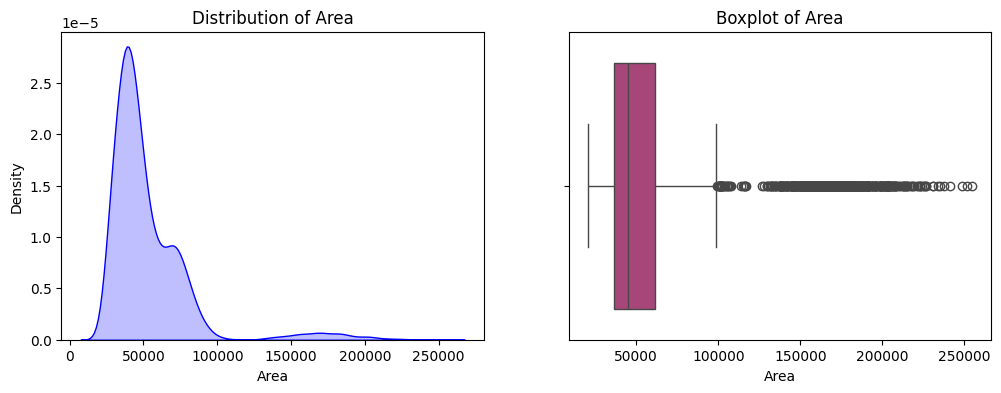

 IQR of Area: 25004.0


In [12]:
plot_univariate_distribution(data, column="Area", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- More than 80% data is below 100000 on the scale
- IQR for this feature is 25004
- Data is right-skewed having lot of outliers

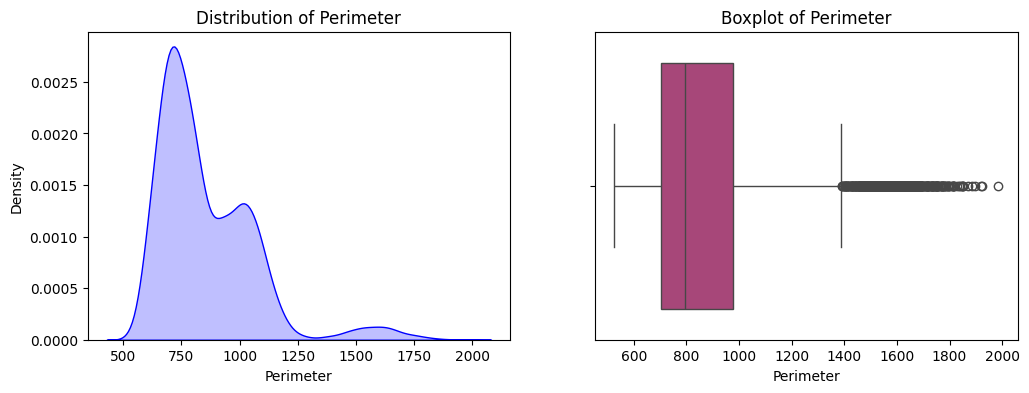

 IQR of Perimeter: 273.68949999999995


In [13]:
plot_univariate_distribution(data, column="Perimeter", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- More than 80% data is below 1250 on the scale
- IQR of Perimeter: 273.689
- Data is right-skewed having lot of outliers

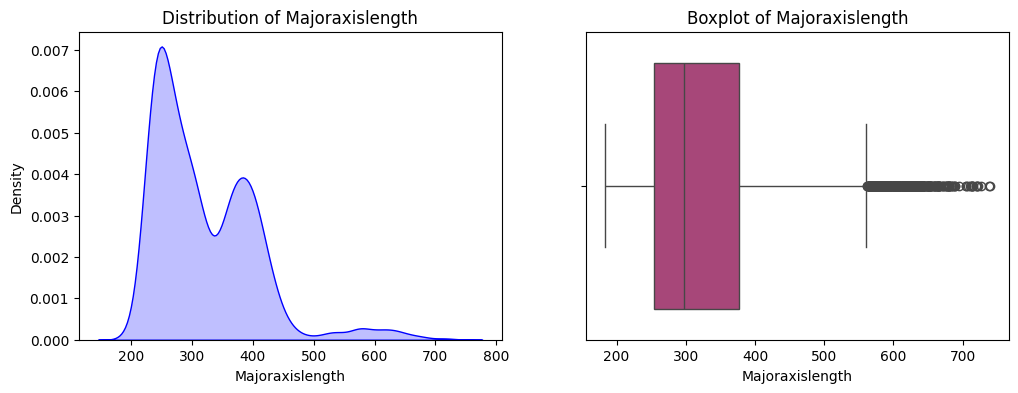

 IQR of Majoraxislength: 123.19137975000001


In [14]:
plot_univariate_distribution(data, column="MajorAxisLength", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- More than 90% data is below 500 on the scale
- IQR of Majoraxislength: 123.191
- Data is right-skewed having lot of outliers

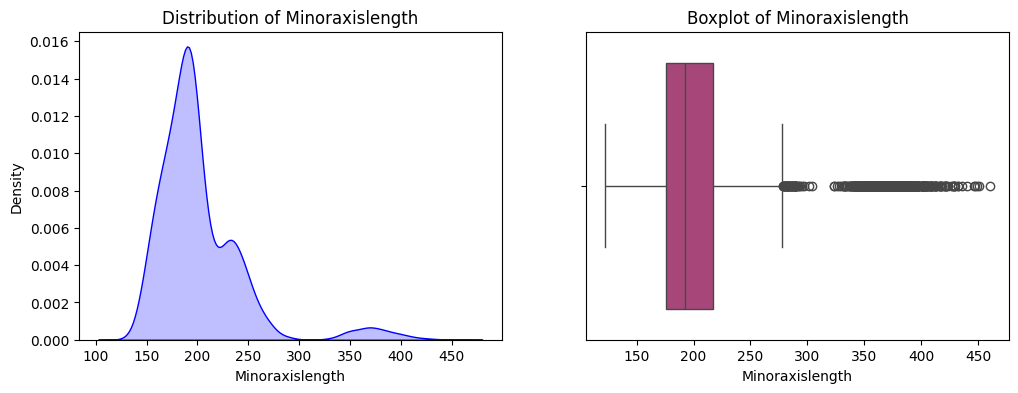

 IQR of Minoraxislength: 41.18357125000003


In [15]:
plot_univariate_distribution(data, column="MinorAxisLength", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- Around 75% data is within the range of 250 on the scale
- IQR of Minoraxislength: 41.18
- Data is right-skewed having lot of outliers

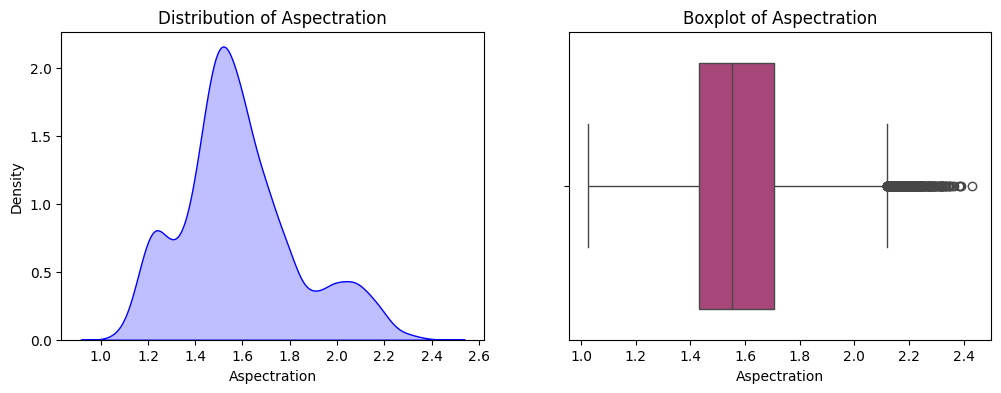

 IQR of Aspectration: 0.2748019955000003


In [16]:
plot_univariate_distribution(data, column="AspectRation", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- Around 75% data is below 1.8 on the scale
- IQR of Aspectration: 0.28
- Data is right-skewed having lot of outliers

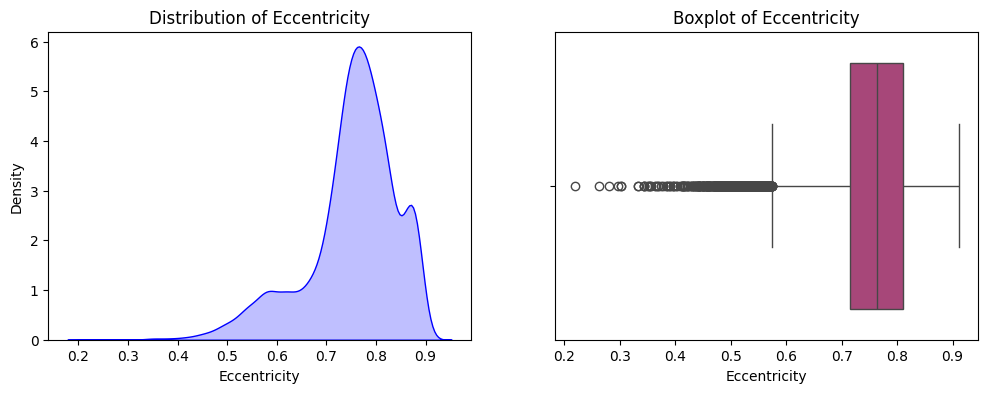

 IQR of Eccentricity: 0.09453823800000005


In [17]:
plot_univariate_distribution(data, column="Eccentricity", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- Around 25% data is around 0.72 on the scale
- IQR of Eccentricity: 0.094
- Data is left-skewed having lot of outliers

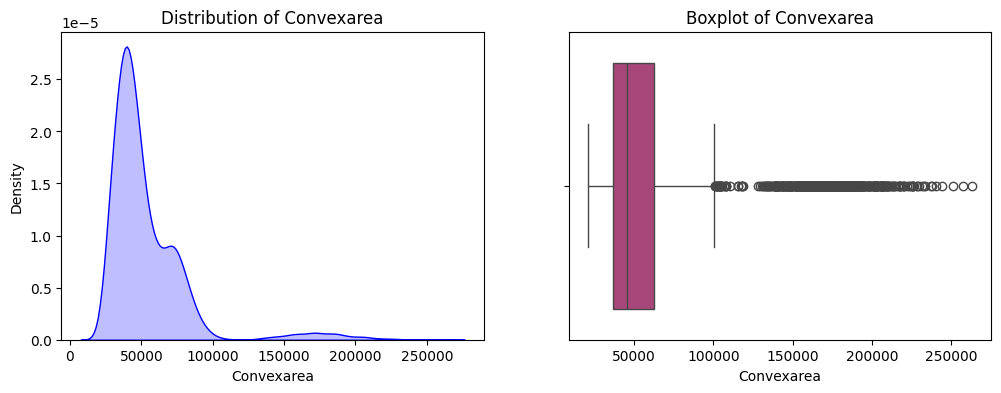

 IQR of Convexarea: 25579.5


In [18]:
plot_univariate_distribution(data, column="ConvexArea", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- About 97% data is below 100000 on the scale
- IQR of Convexarea: 25579.5
- Data is right-skewed having lot of outliers

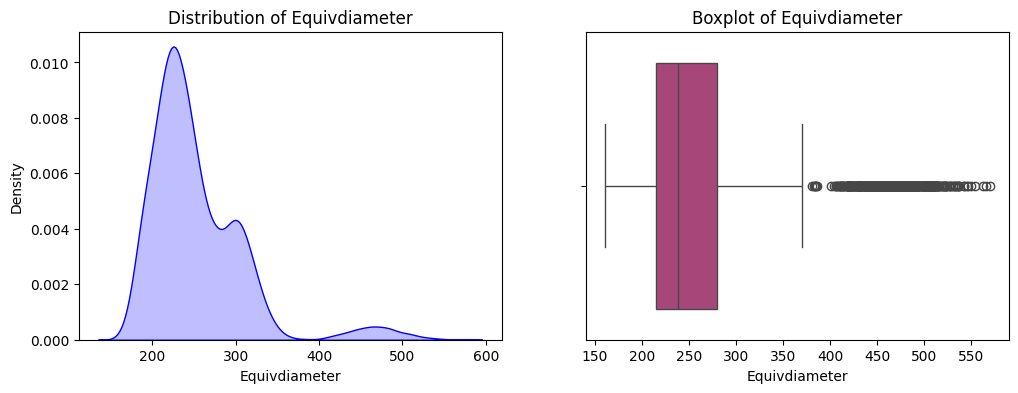

 IQR of Equivdiameter: 64.37846324999998


In [19]:
plot_univariate_distribution(data, column="EquivDiameter", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- About 97% data is around 350 on the scale
- IQR of Equivdiameter: 64.378
- Data is right-skewed having lot of outliers

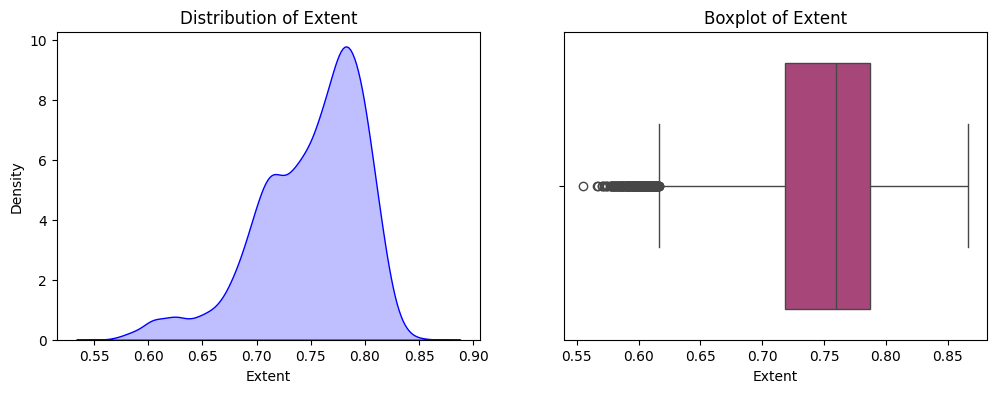

 IQR of Extent: 0.06821796899999999


In [20]:
plot_univariate_distribution(data, column="Extent", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- About 25% data is around 0.71 on the scale
- IQR of Extent: 0.068
- Data is left-skewed having lot of outliers

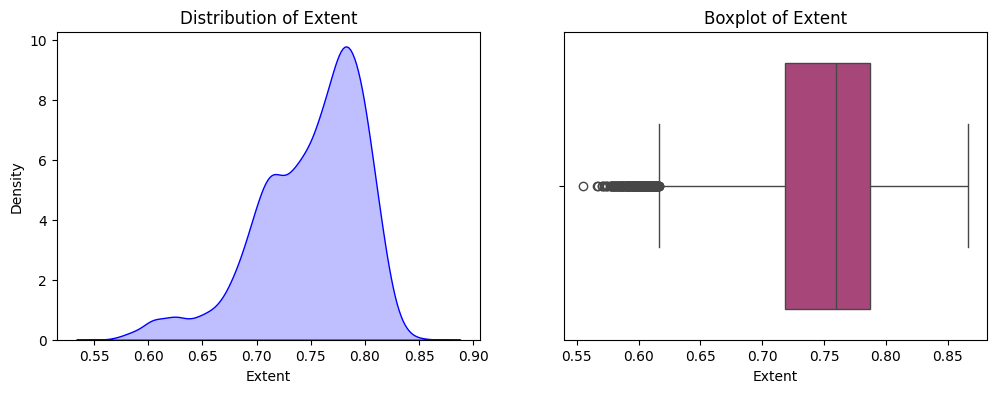

 IQR of Extent: 0.06821796899999999


In [21]:
plot_univariate_distribution(data, column="Extent", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- About 25% data is around 0.71 on the scale
- IQR of Extent: 0.068
- Data is left-skewed having lot of outliers

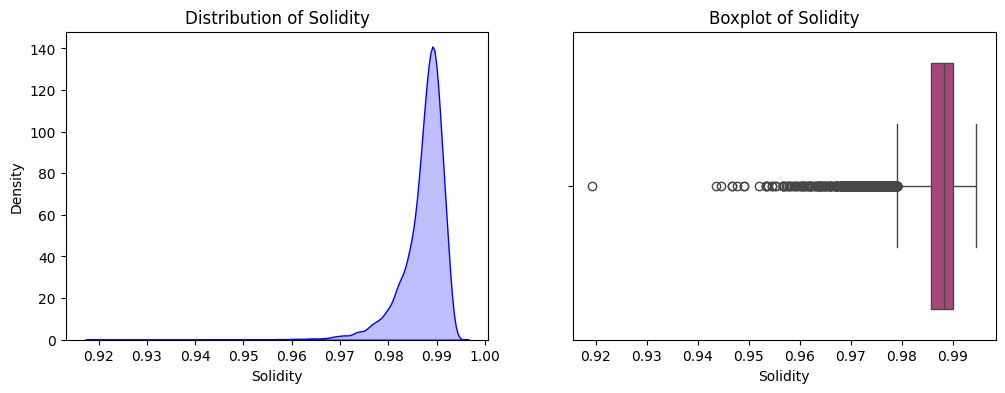

 IQR of Solidity: 0.004342711500000096


In [22]:
plot_univariate_distribution(data, column="Solidity", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- About 25% data is around 0.985 on the scale
- IQR of Solidity: 0.0043
- Data is left-skewed having lot of outliers

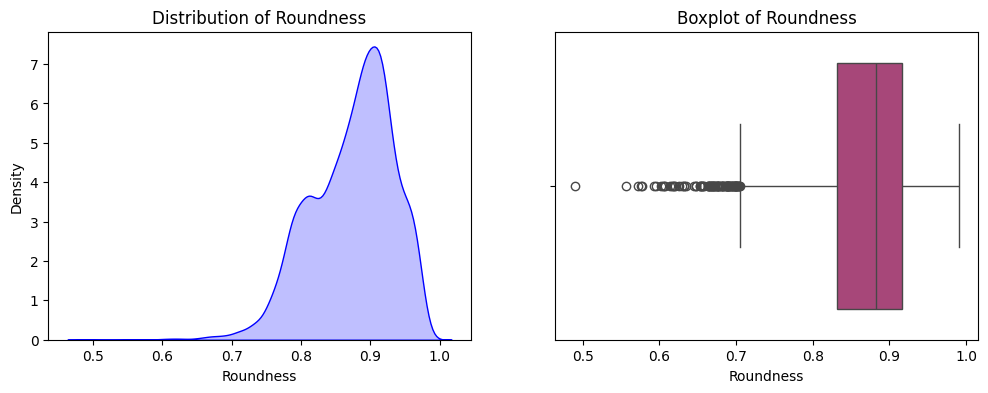

 IQR of Roundness: 0.08477250399999992


In [23]:
plot_univariate_distribution(data, column="roundness", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- About 25% data is around 0.81 on the scale
- IQR of Roundness: 0.085
- Data is left-skewed having lot of outliers

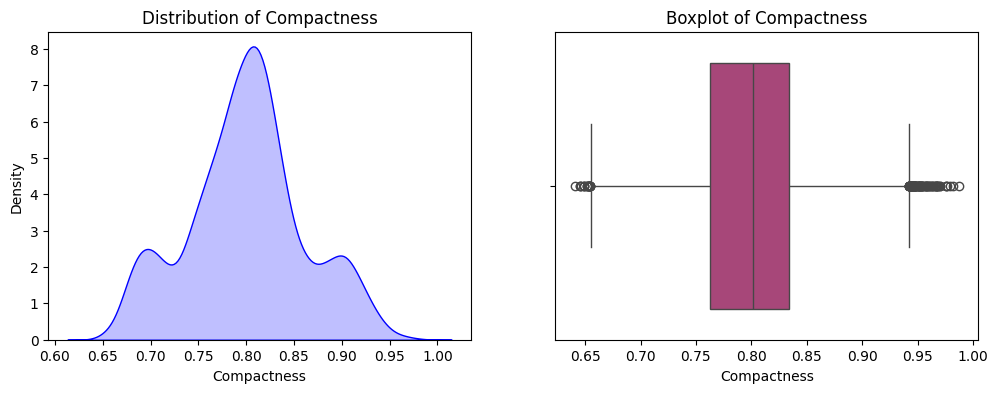

 IQR of Compactness: 0.07180116400000003


In [24]:
plot_univariate_distribution(data, column="Compactness", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- About 25% data is around 0.75 on the scale
- IQR of Compactness: 0.0718
- Data is having outliers at both the end

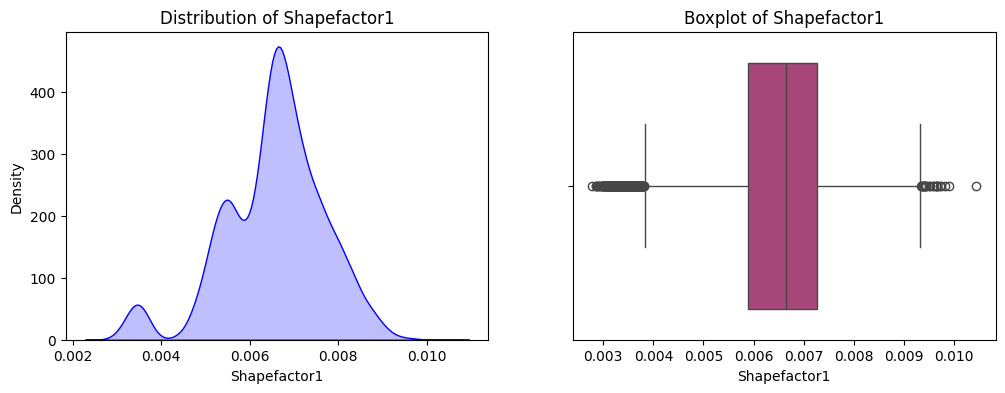

 IQR of Shapefactor1: 0.0013715030000000005


In [25]:
plot_univariate_distribution(data, column="ShapeFactor1", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- About 25% data is around 0.0057 on the scale
- IQR of Shapefactor1: 0.001371
- Data is having outliers at both the end

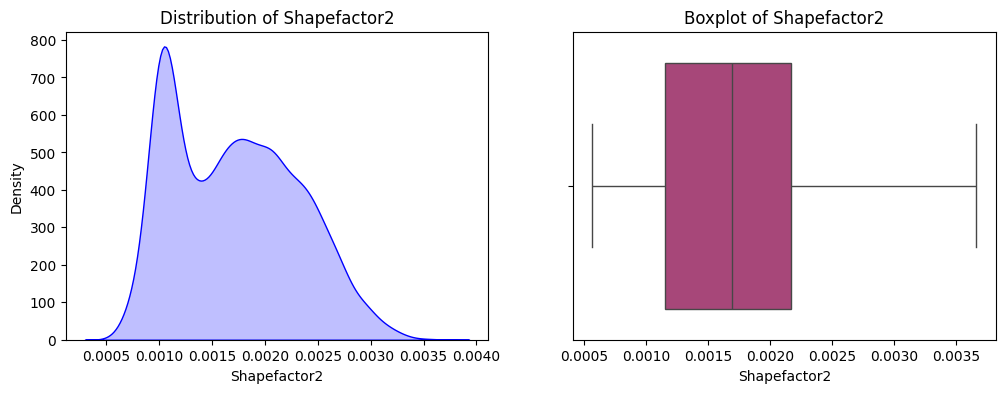

 IQR of Shapefactor2: 0.001016748


In [26]:
plot_univariate_distribution(data, column="ShapeFactor2", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- About 25% data is around 0.0011 on the scale
- IQR of Shapefactor2: 0.00101

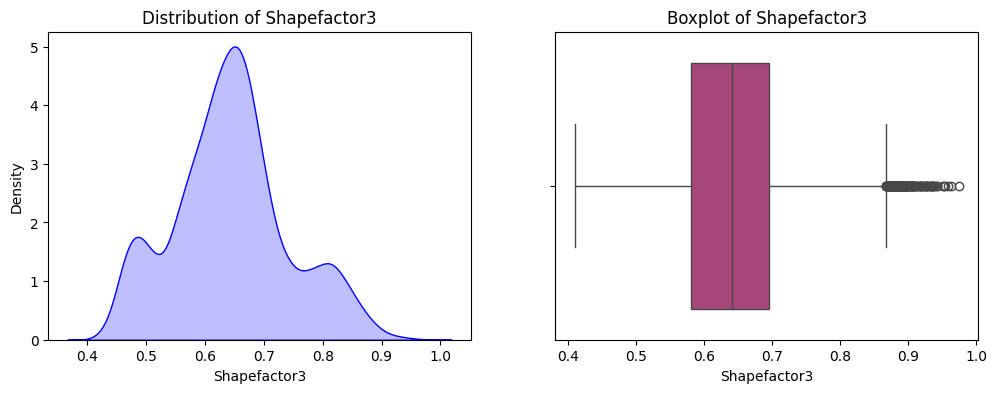

 IQR of Shapefactor3: 0.11464769349999993


In [27]:
plot_univariate_distribution(data, column="ShapeFactor3", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- About 25% data is around 0.59 on the scale
- IQR of Shapefactor3: 0.1146
- Data is right-skewed and having outliers

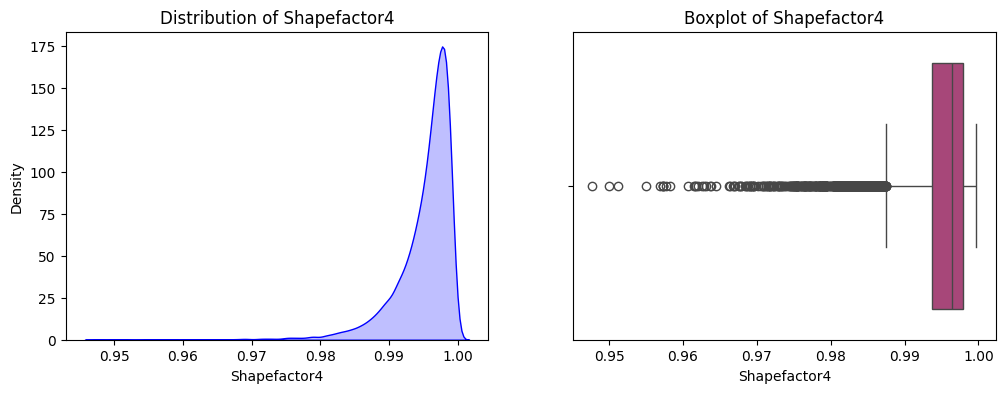

 IQR of Shapefactor4: 0.004179647499999994


In [28]:
plot_univariate_distribution(data, column="ShapeFactor4", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- About 25% data is around 0.994 on the scale
- IQR of Shapefactor4: 0.00418
- Data is left-skewed and having outliers


<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Bi-variate Analysis.</u></li>
</ul>
</p>

---


In [29]:
def plot_bivariate_relationship(df, x_column, y_column, x_label=None, y_label=None, plot_type="scatter", plot_width=6, plot_height=4):
    """
    This function plots the bivariate relationship between two specified columns in the DataFrame.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    x_column (str): The name of the column to be plotted on the x-axis.
    y_column (str): The name of the column to be plotted on the y-axis.
    x_label (str): The label for the x-axis.
    y_label (str): The label for the y-axis.
    plot_type (str): The type of plot to create ("scatter" or "line" or "crosstab" or "boxplot").
    plot_width (int): The width of the plot in inches.
    plot_height (int): The height of the plot in inches.

    Returns:
    None
    """

    fig = plt.figure(figsize=(plot_width, plot_height))

    if plot_type == "scatter":
        ax = sns.scatterplot(x=df[x_column], y=df[y_column], color='blue')

        plt.title(f'Scatter Plot of {y_column.capitalize() if y_label is None else y_label.capitalize()} vs {x_column.capitalize() if x_label is None else x_label.capitalize()}')

    elif plot_type == "line":
        ax = sns.lineplot(x=df[x_column], y=df[y_column], color='blue')

        plt.title(f'Line Plot of {y_column.capitalize() if y_label is None else y_label.capitalize()} vs {x_column.capitalize() if x_label is None else x_label.capitalize()}')

    elif plot_type == "countplot":
        ax = sns.countplot(x=df[x_column], hue=df[y_column], palette='magma')

        for p in ax.patches:
            percentage = '{:.2f}%'.format(100 * p.get_height() / total_datapoints)
            x = p.get_x() + p.get_width()/5
            y = p.get_y() + p.get_height()
            ax.annotate(percentage, (x, y))

        plt.title(f'Count Plot of {y_column.capitalize() if y_label is None else y_label.capitalize()} vs {x_column.capitalize() if x_label is None else x_label.capitalize()}')
    elif plot_type == "crosstab":
        crosstab = pd.crosstab(df[x_column], df[y_column])
        ax = crosstab.plot(kind='bar', stacked=True, figsize=fig)

        for p in ax.patches:
            percentage = '{:.2f}%'.format(100 * p.get_height() / total_datapoints)
            x = p.get_x() + p.get_width()/5
            y = p.get_y() + p.get_height()
            ax.annotate(percentage, (x, y))

        plt.title(f'Cross-tabulation of {y_column.capitalize() if y_label is None else y_label.capitalize()} vs {x_column.capitalize() if x_label is None else x_label.capitalize()}')

    elif plot_type == "boxplot":
        ax = sns.boxplot(x=df[x_column], y=df[y_column])

        plt.title(f'Box Plot of {y_column.capitalize() if y_label is None else y_label.capitalize()} vs {x_column.capitalize() if x_label is None else x_label.capitalize()}')

    else:
        raise ValueError("Invalid plot type. Use 'scatter' or 'line'  or 'crosstab' or 'boxplot'.")


    plt.ylabel(y_column.capitalize() if y_label is None else y_label.capitalize())
    plt.xlabel(x_column.capitalize() if x_label is None else x_label.capitalize())

    plt.grid(visible=True)
    plt.show()

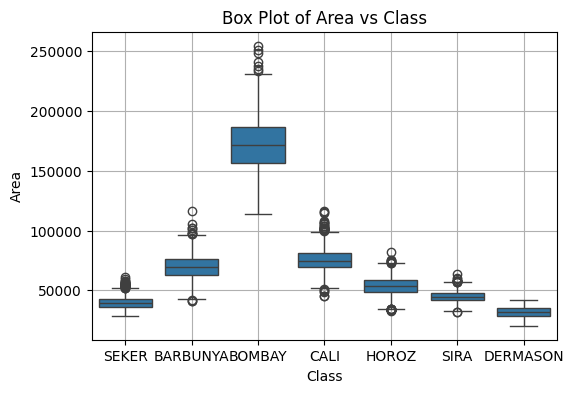

In [30]:
plot_bivariate_relationship(data, x_column="Class", y_column="Area", plot_type="boxplot", x_label="Class", y_label="Area")

---
<a name = Section2></a>
#### Insights:

- Except DERMASON class all the classes is having outliers w.r.t. Area

We have to keep this point into consideration at the time of outlier treatment

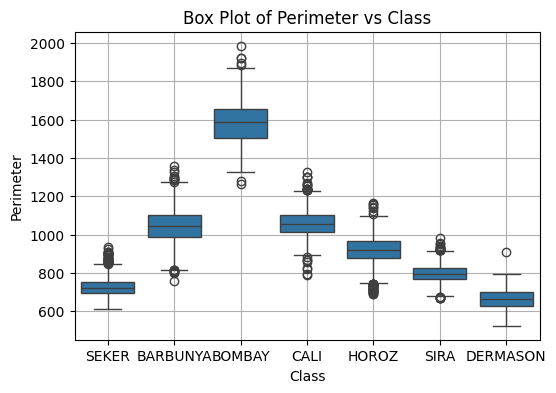

In [31]:
plot_bivariate_relationship(data, x_column="Class", y_column="Perimeter", plot_type="boxplot", x_label="Class", y_label="Perimeter")

---
<a name = Section2></a>
#### Insights:

- All the classes is having outliers w.r.t. Perimeter

We have to keep this point into consideration at the time of outlier treatment

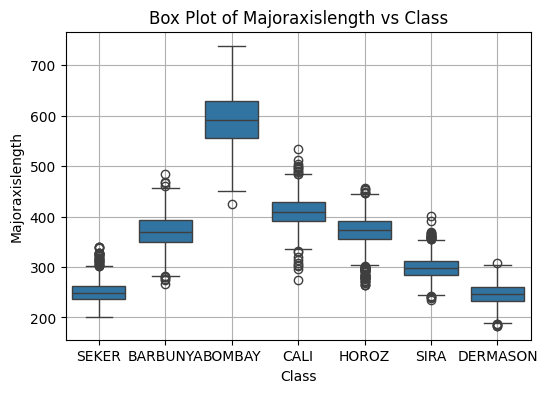

In [32]:
plot_bivariate_relationship(data, x_column="Class", y_column="MajorAxisLength", plot_type="boxplot", x_label="Class", y_label="MajorAxisLength")

---
<a name = Section2></a>
#### Insights:

- All the classes is having outliers w.r.t. MajorAxisLength

We have to keep this point into consideration at the time of outlier treatment

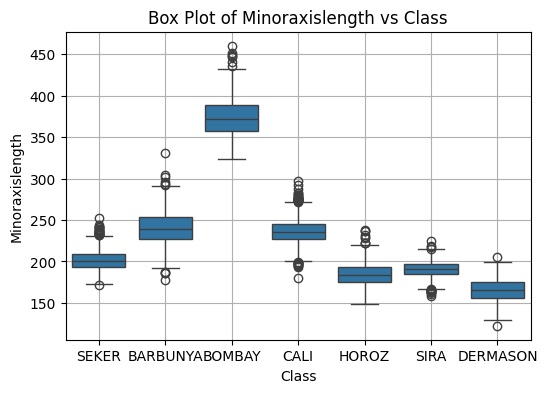

In [33]:
plot_bivariate_relationship(data, x_column="Class", y_column="MinorAxisLength", plot_type="boxplot", x_label="Class", y_label="MinorAxisLength")

---
<a name = Section2></a>
#### Insights:

- All the classes is having outliers w.r.t. MinorAxisLength

We have to keep this point into consideration at the time of outlier treatment

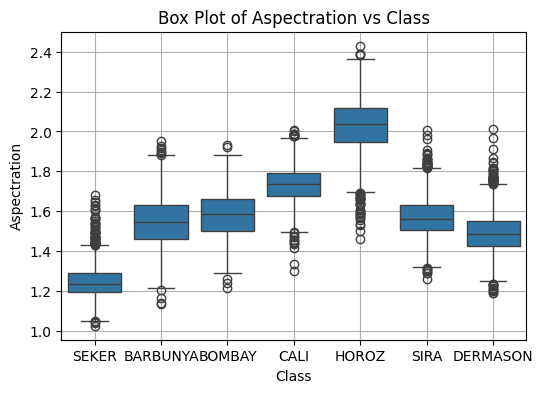

In [34]:
plot_bivariate_relationship(data, x_column="Class", y_column="AspectRation", plot_type="boxplot", x_label="Class", y_label="AspectRation")

---
<a name = Section2></a>
#### Insights:

- All the classes is having outliers w.r.t. AspectRation

We have to keep this point into consideration at the time of outlier treatment

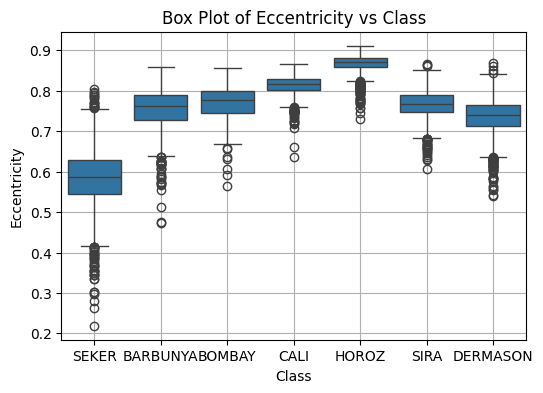

In [35]:
plot_bivariate_relationship(data, x_column="Class", y_column="Eccentricity", plot_type="boxplot", x_label="Class", y_label="Eccentricity")

---
<a name = Section2></a>
#### Insights:

- All the classes is having outliers w.r.t. Eccentricity

We have to keep this point into consideration at the time of outlier treatment

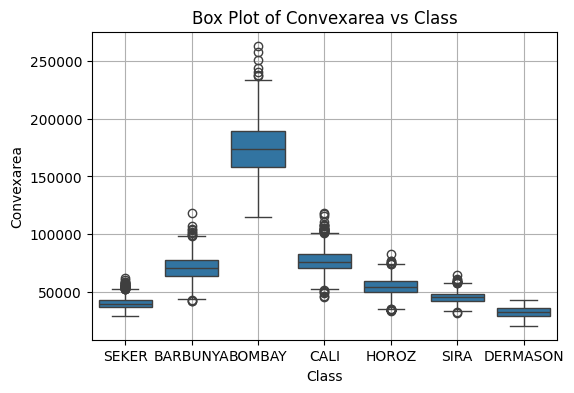

In [36]:
plot_bivariate_relationship(data, x_column="Class", y_column="ConvexArea", plot_type="boxplot", x_label="Class", y_label="ConvexArea")

---
<a name = Section2></a>
#### Insights:

- Except DERMASON class all the classes is having outliers w.r.t. ConvexArea

We have to keep this point into consideration at the time of outlier treatment

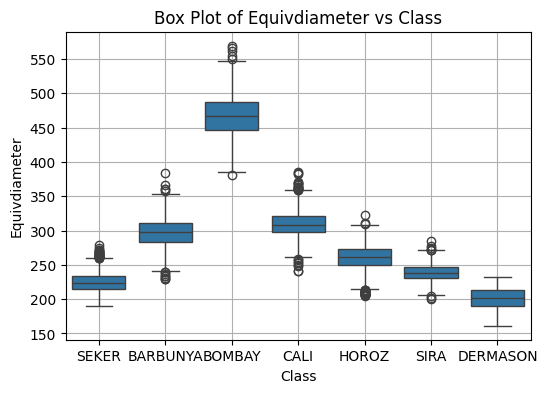

In [37]:
plot_bivariate_relationship(data, x_column="Class", y_column="EquivDiameter", plot_type="boxplot", x_label="Class", y_label="EquivDiameter")

---
<a name = Section2></a>
#### Insights:

- Except DERMASON class all the classes is having outliers w.r.t. EquivDiameter

We have to keep this point into consideration at the time of outlier treatment

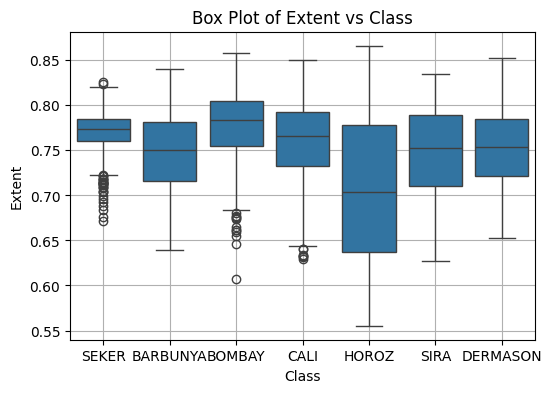

In [38]:
plot_bivariate_relationship(data, x_column="Class", y_column="Extent", plot_type="boxplot", x_label="Class", y_label="Extent")

---
<a name = Section2></a>
#### Insights:

- 3 classes-SEKER, BOMBAY and CALI is having outliers w.r.t. Extent

We have to keep this point into consideration at the time of outlier treatment

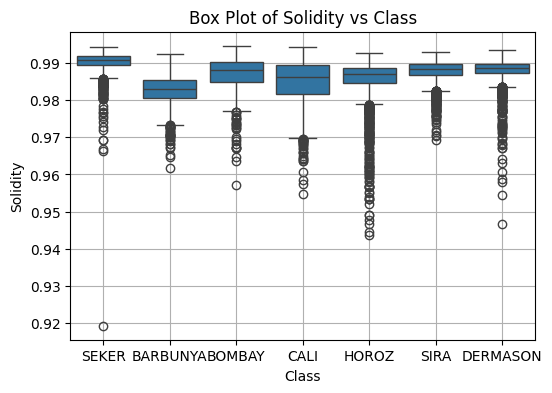

In [39]:
plot_bivariate_relationship(data, x_column="Class", y_column="Solidity", plot_type="boxplot", x_label="Class", y_label="Solidity")

---
<a name = Section2></a>
#### Insights:

- All the classes is having outliers w.r.t. Solidity

We have to keep this point into consideration at the time of outlier treatment

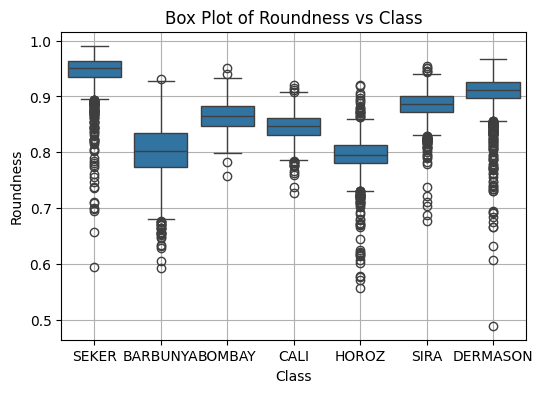

In [40]:
plot_bivariate_relationship(data, x_column="Class", y_column="roundness", plot_type="boxplot", x_label="Class", y_label="roundness")

---
<a name = Section2></a>
#### Insights:

- All the classes is having outliers w.r.t. roundness

We have to keep this point into consideration at the time of outlier treatment

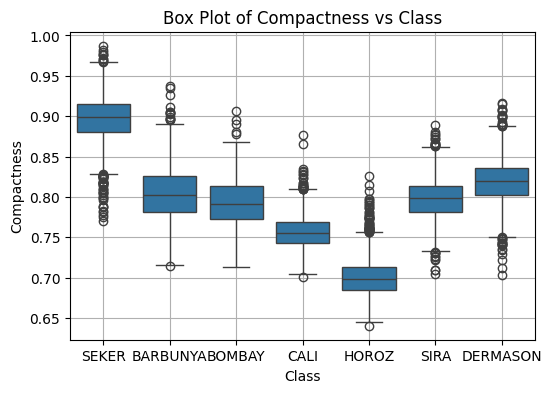

In [41]:
plot_bivariate_relationship(data, x_column="Class", y_column="Compactness", plot_type="boxplot", x_label="Class", y_label="Compactness")

---
<a name = Section2></a>
#### Insights:

- All the classes is having outliers w.r.t. Compactness

We have to keep this point into consideration at the time of outlier treatment

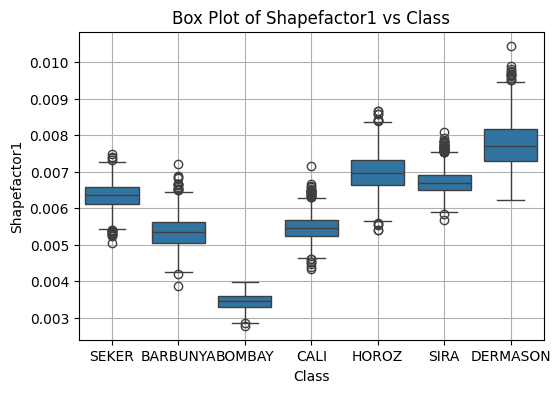

In [42]:
plot_bivariate_relationship(data, x_column="Class", y_column="ShapeFactor1", plot_type="boxplot", x_label="Class", y_label="ShapeFactor1")

---
<a name = Section2></a>
#### Insights:

- All the classes is having outliers w.r.t. ShapeFactor1

We have to keep this point into consideration at the time of outlier treatment

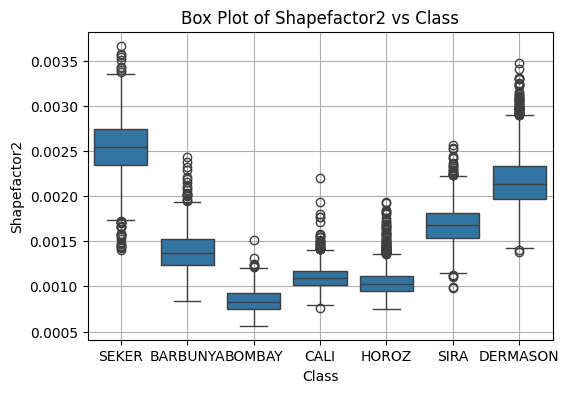

In [43]:
plot_bivariate_relationship(data, x_column="Class", y_column="ShapeFactor2", plot_type="boxplot", x_label="Class", y_label="ShapeFactor2")

---
<a name = Section2></a>
#### Insights:

- All the classes is having outliers w.r.t. ShapeFactor2

We have to keep this point into consideration at the time of outlier treatment

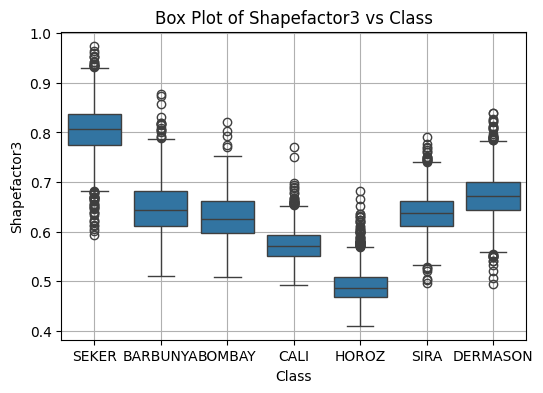

In [44]:
plot_bivariate_relationship(data, x_column="Class", y_column="ShapeFactor3", plot_type="boxplot", x_label="Class", y_label="ShapeFactor3")

---
<a name = Section2></a>
#### Insights:

- All the classes is having outliers w.r.t. ShapeFactor3

We have to keep this point into consideration at the time of outlier treatment

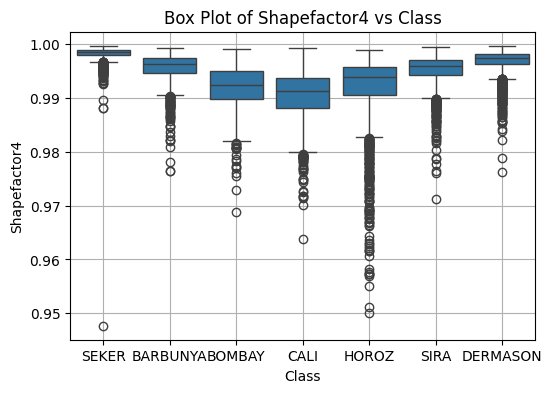

In [45]:
plot_bivariate_relationship(data, x_column="Class", y_column="ShapeFactor4", plot_type="boxplot", x_label="Class", y_label="ShapeFactor4")

---
<a name = Section2></a>
#### Insights:

- All the classes is having outliers w.r.t. ShapeFactor4

We have to keep this point into consideration at the time of outlier treatment

---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Perform Data Wrangling.</u></li>
</ul>
</p>

---


In [46]:
def copy_dataframe(df):
    """
    This function creates and returns a copy of the given DataFrame
    to ensure that the original DataFrame remains unchanged during analysis.
    Also it removes duplicate data points if there are any in the DataFrame.

    Parameters:
    df (pd.DataFrame): The DataFrame to copy.

    Returns:
    pd.DataFrame: A copy of the input DataFrame.
    """
    df_copy = df.copy()

    # dropping duplicate data and keeping the first occurrence of each duplicate
    df_copy.drop_duplicates(inplace=True, keep='first')
    return df_copy

In [47]:
clean_data = copy_dataframe(data)

clean_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13543 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13543 non-null  int64  
 1   Perimeter        13543 non-null  float64
 2   MajorAxisLength  13543 non-null  float64
 3   MinorAxisLength  13543 non-null  float64
 4   AspectRation     13543 non-null  float64
 5   Eccentricity     13543 non-null  float64
 6   ConvexArea       13543 non-null  int64  
 7   EquivDiameter    13543 non-null  float64
 8   Extent           13543 non-null  float64
 9   Solidity         13543 non-null  float64
 10  roundness        13543 non-null  float64
 11  Compactness      13543 non-null  float64
 12  ShapeFactor1     13543 non-null  float64
 13  ShapeFactor2     13543 non-null  float64
 14  ShapeFactor3     13543 non-null  float64
 15  ShapeFactor4     13543 non-null  float64
 16  Class            13543 non-null  object 
dtypes: float64(14), i

In [48]:
le = LabelEncoder()
clean_data['Class_encoded'] = le.fit_transform(clean_data['Class'].astype(str))
distinct_pairs = clean_data[['Class','Class_encoded']].drop_duplicates().reset_index(drop=True)
print(distinct_pairs)

      Class  Class_encoded
0     SEKER              5
1  BARBUNYA              0
2    BOMBAY              1
3      CALI              2
4     HOROZ              4
5      SIRA              6
6  DERMASON              3


In [49]:
dictColumns = analyze_data(clean_data)
new_numerical_columns = dictColumns["numerical_columns"]
new_categorical_columns = dictColumns["categorical_columns"]

First 5 rows of the DataFrame:
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395  610.29100        208.17812        173.88875       1.19719   
1  28734  638.01800        200.52480        182.73442       1.09736   
2  29380  624.11000        212.82613        175.93114       1.20971   
3  30008  645.88400        210.55800        182.51652       1.15364   
4  30140  620.13400        201.84788        190.27928       1.06080   

   Eccentricity  ConvexArea  EquivDiameter  Extent  Solidity  roundness  \
0       0.54981       28715      190.14110 0.76392   0.98886    0.95803   
1       0.41179       29172      191.27275 0.78397   0.98499    0.88703   
2       0.56273       29690      193.41090 0.77811   0.98956    0.94785   
3       0.49862       30724      195.46706 0.78268   0.97670    0.90394   
4       0.33368       30417      195.89650 0.77310   0.99089    0.98488   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  \
0      0.9


<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Multivariate Analysis: Correlation Matrix</u></li>
</ul>
</p>

---


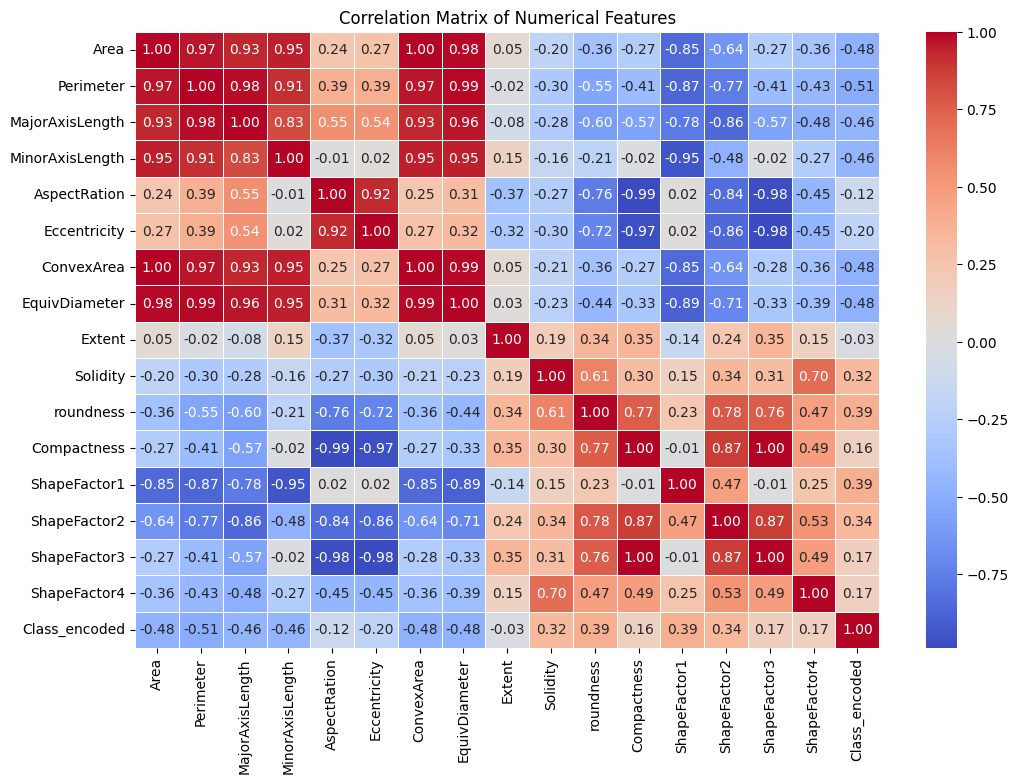

In [50]:
plt.figure(figsize=(12,8))
sns.heatmap(clean_data[new_numerical_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

---
<a name = Section2></a>
#### Insights:

- 'Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'ConvexArea' and 'EquivDiameter' are strong (-)ve predictors for our target
- 'Solidity', 'roundness', 'ShapeFactor1' and 'ShapeFactor2' are strong (+)ve predictors for our target


<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Outlier Treatment</u></li>
</ul>
</p>

---


In [51]:
# Define exceptions as list of (Class, feature) pairs to SKIP winsorization.
exceptions = [("DERMASON", "Area"),("DERMASON", "ConvexArea"), ("DERMASON", "EquivDiameter"), ("BARBUNYA", "Extent"), ("HOROZ", "Extent"), ("SIRA","Extent"),
 ("DERMASON", "Extent")]
exceptions = set(exceptions)
print('Exceptions (class,feature) set:')
print(exceptions)

Exceptions (class,feature) set:
{('BARBUNYA', 'Extent'), ('SIRA', 'Extent'), ('DERMASON', 'Area'), ('DERMASON', 'EquivDiameter'), ('DERMASON', 'Extent'), ('DERMASON', 'ConvexArea'), ('HOROZ', 'Extent')}


In [52]:
def detect_outliers_iqr_by_class(df, group_col='Class', cols=None, k=1.5, exceptions=None):
    """
    This function detects outliers in a DataFrame using the Interquartile Range (IQR) 
    method, grouped by a specified column. It calculates the IQR for each group and 
    identifies outliers based on the lower and upper bounds defined by the IQR. The 
    function returns a DataFrame summarizing the number of outliers and their 
    proportion for each group and feature. 

    Parameters:
    df (pd.DataFrame): The DataFrame to analyze for outliers.
    group_col (str): The column by which to group the data.
    cols (list): The columns to analyze for outliers. If None, all numeric columns are analyzed.
    k (float): The multiplier for the IQR to define the bounds for outlier detection.
    exceptions (set): A set of (Class, feature) pairs to exclude from outlier detection.

    Returns:
    pd.DataFrame: A DataFrame summarizing the number of outliers and their proportion 
    for each group and feature.

    """
    if cols is None:
        cols = numerical_columns
    rows = []
    for cls, g in df.groupby(group_col):
        for col in cols:
            if exceptions is not None and (cls, col) in exceptions:
                continue  # Skip this class if it's in the exceptions set
            s = g[col].dropna()
            q1 = s.quantile(0.25)
            q3 = s.quantile(0.75)
            iqr = q3 - q1
            lower = q1 - k * iqr
            upper = q3 + k * iqr
            mask = (g[col] < lower) | (g[col] > upper)
            n_out = int(mask.sum())
            frac = float(n_out / g.shape[0]) if g.shape[0] else 0.0
            rows.append({
                group_col: cls, "feature": col,
                "q1": q1, "q3": q3, "iqr": iqr,
                "lower": lower, "upper": upper,
                "n_outliers": n_out, "outlier_fraction": frac
            })

    per_class_bounds = pd.DataFrame(rows)
    per_class_bounds.to_csv("data\\output\\per_class_iqr_bounds.csv", index=False)
    with open('data\\output\\per_class_iqr_bounds.pkl','wb') as f:
        pickle.dump(per_class_bounds, f)

    return pd.DataFrame(per_class_bounds).sort_values(["n_outliers"], ascending=False)

In [53]:
def winsorize_iqr_by_class(df, group_col='Class', cols=None, k=1.5):
    """
    Winsorize numeric features per-class using either provided bounds or IQR computed per-class.

    When `bounds_df` is provided, this function WILL ONLY apply winsorization for class/feature
    pairs present in `bounds_df`. Any missing class/feature entry will be skipped (no clipping).
    This enforces strict application of precomputed bounds and avoids accidental leakage.

    Parameters:
    df (pd.DataFrame): DataFrame to winsorize (a copy is returned).
    group_col (str): Column name to group by (e.g., 'Class').
    cols (list): Numeric columns to winsorize. If None, uses `numerical_columns` from analysis.
    k (float): IQR multiplier used when bounds_df is not provided.

    Returns:
    pd.DataFrame: winsorized copy of `df`.
    """
    bounds_df = pd.DataFrame()
    try:
        with open('data\\output\\per_class_iqr_bounds.pkl','rb') as f:
            bounds_df = pickle.load(f)
            print('Loaded per_class_bounds:')
            display(bounds_df.head())
    except FileNotFoundError:
        # Fallback to computing bounds if file not found
        print('per_class_iqr_bounds.pkl not found — compute bounds first by running the bounds cell')
    

    if cols is None:
        cols = numerical_columns
    df_w = df.copy()
    if bounds_df is not None:
        # convert to nested dict for fast lookup: bounds_map[class][feature] = (lower, upper)
        bmap = {}
        for _, r in bounds_df.iterrows():
            cls = r['Class']
            feat = r['feature']
            lower = r['lower']
            upper = r['upper']
            bmap.setdefault(cls, {})[feat] = (lower, upper)
        for cls, g in df.groupby(group_col):
            idx = g.index
            cls_bounds = bmap.get(cls, {})
            # If no bounds defined for this class, skip entire class
            if not cls_bounds:
                continue
            for col in cols:
                if col in cls_bounds:
                    lower, upper = cls_bounds[col]
                    df_w.loc[idx, col] = np.clip(df_w.loc[idx, col], lower, upper)
                else:
                    # skip winsorization for this specific class/feature pair
                    pass
    return df_w


In [54]:
summary = detect_outliers_iqr_by_class(clean_data, group_col='Class', cols=numerical_columns, k=1.5)
print(summary.head(20))

        Class          feature        q1        q3      iqr     lower  \
63   DERMASON     ShapeFactor4   0.99628   0.99812  0.00184   0.99352   
73      HOROZ         Solidity   0.98468   0.98863  0.00395   0.97875   
57   DERMASON         Solidity   0.98733   0.98987  0.00254   0.98351   
79      HOROZ     ShapeFactor4   0.99056   0.99579  0.00523   0.98272   
105      SIRA         Solidity   0.98687   0.98976  0.00289   0.98254   
58   DERMASON        roundness   0.89715   0.92496  0.02781   0.85543   
111      SIRA     ShapeFactor4   0.99428   0.99717  0.00289   0.98994   
95      SEKER     ShapeFactor4   0.99808   0.99901  0.00093   0.99668   
90      SEKER        roundness   0.93550   0.96290  0.02740   0.89440   
89      SEKER         Solidity   0.98949   0.99194  0.00245   0.98581   
77      HOROZ     ShapeFactor2   0.00095   0.00111  0.00016   0.00071   
74      HOROZ        roundness   0.77988   0.81266  0.03277   0.73072   
69      HOROZ     Eccentricity   0.85811   0.88161 

In [55]:
# Use precomputed per_class_bounds to apply winsorization with exceptions (only for class/feature pairs present in bounds)
try:
    clean_winsorized = winsorize_iqr_by_class(clean_data, group_col='Class', cols=numerical_columns, k=1.5)
    print('Applied winsorization using loaded per_class_bounds (with exceptions)')
except NameError:
    print('per_class_bounds not found — cannot apply winsorization with exceptions. Please compute bounds first.')


Loaded per_class_bounds:


,Class,feature,q1,q3,iqr,lower,upper,n_outliers,outlier_fraction
0,BARBUNYA,Area,62931.00000,76306.50000,13375.50000,42867.75000,96369.75000,12,0.00908
1,BARBUNYA,Perimeter,989.12900,1103.84725,114.71825,817.05163,1275.92463,20,0.01513
2,BARBUNYA,MajorAxisLength,348.66736,392.83528,44.16792,282.41549,459.08715,10,0.00756
3,BARBUNYA,MinorAxisLength,227.46628,253.24144,25.77516,188.80354,291.90418,10,0.00756
4,BARBUNYA,AspectRation,1.46042,1.62982,0.16940,1.20633,1.88391,11,0.00832


Applied winsorization using loaded per_class_bounds (with exceptions)


In [56]:
clean_winsorized.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class_encoded
count,13543.00000,13543.00000,13543.00000,13543.00000,13543.00000,13543.00000,13543.00000,13543.00000,13543.00000,13543.00000,13543.00000,13543.00000,13543.00000,13543.00000,13543.00000,13543.00000,13543.00000
mean,53022.47862,854.87376,319.90293,202.33420,1.58077,0.75088,53741.94858,253.01856,0.74988,0.98740,0.87479,0.80030,0.00656,0.00172,0.64418,0.99526,3.53031
std,29329.76324,214.45184,85.74760,44.97148,0.24497,0.09087,29784.09944,59.24591,0.04887,0.00385,0.05757,0.06138,0.00113,0.00059,0.09845,0.00370,1.83299
min,20420.00000,524.73600,187.53588,128.74516,1.04860,0.41549,20684.00000,161.24376,0.55531,0.96977,0.68044,0.64122,0.00286,0.00056,0.41034,0.97988,0.00000
25%,36282.50000,703.26800,253.08681,175.88636,1.43039,0.71522,36673.00000,214.93328,0.71909,0.98580,0.83540,0.76278,0.00589,0.00116,0.58184,0.99373,2.00000
50%,44580.00000,793.94400,296.90849,192.49452,1.54965,0.76392,45122.00000,238.28579,0.75990,0.98829,0.88432,0.80161,0.00664,0.00170,0.64258,0.99643,3.00000
75%,61366.00000,977.05950,376.19862,217.21741,1.70392,0.81027,62349.50000,279.52391,0.78685,0.99002,0.91702,0.83443,0.00727,0.00217,0.69628,0.99789,5.00000
max,231430.62500,1881.55525,738.86015,434.73277,2.37550,0.91142,236708.62500,548.53458,0.86619,0.99468,0.99069,0.96742,0.00945,0.00336,0.93139,0.99973,6.00000


In [57]:
clean_winsorized.duplicated().sum()

np.int64(0)


<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Comparative Visualization</u></li>
</ul>
</p>

---


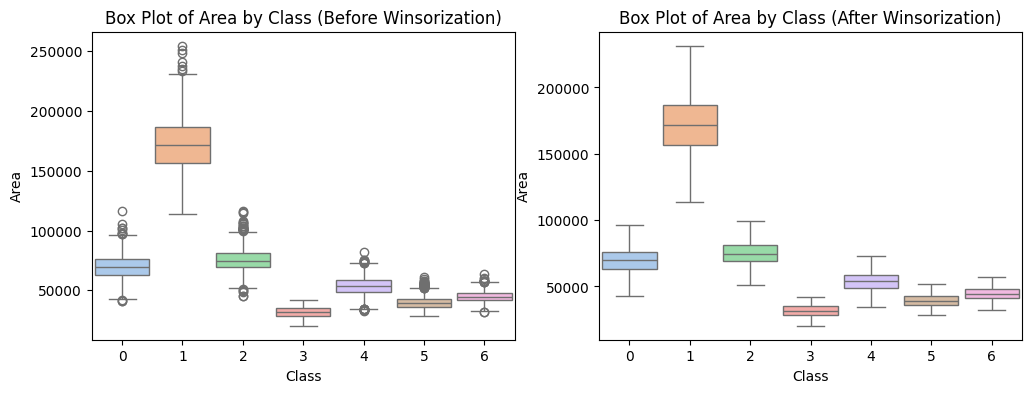

In [58]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.boxplot(x=clean_data['Class_encoded'], y=clean_data['Area'],width=0.9,palette='pastel', ax=ax1)
ax1.set_title('Box Plot of Area by Class (Before Winsorization)')
ax1.set_xlabel('Class')
ax1.set_ylabel('Area')

sns.boxplot(x=clean_winsorized['Class_encoded'], y=clean_winsorized['Area'],width=0.9,palette='pastel', ax=ax2)
ax2.set_title('Box Plot of Area by Class (After Winsorization)')
ax2.set_xlabel('Class')
ax2.set_ylabel('Area')
plt.show()

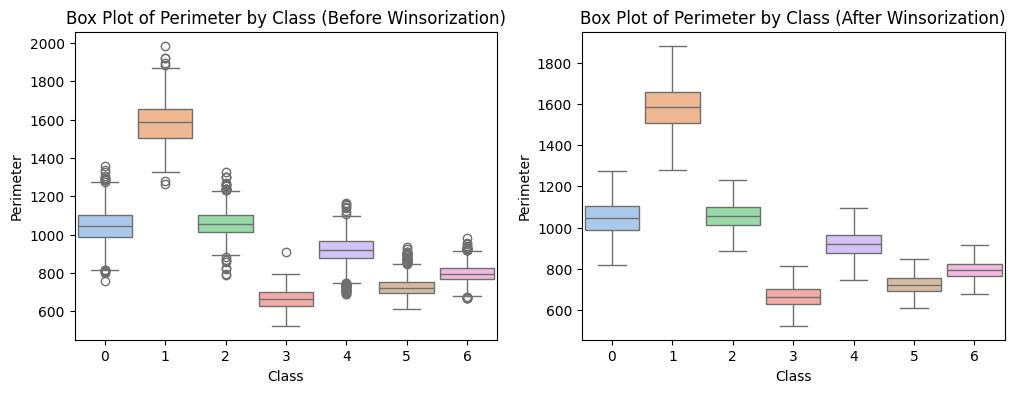

In [59]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.boxplot(x=clean_data['Class_encoded'], y=clean_data['Perimeter'],width=0.9,palette='pastel', ax=ax1)
ax1.set_title('Box Plot of Perimeter by Class (Before Winsorization)')
ax1.set_xlabel('Class')
ax1.set_ylabel('Perimeter')

sns.boxplot(x=clean_winsorized['Class_encoded'], y=clean_winsorized['Perimeter'],width=0.9,palette='pastel', ax=ax2)
ax2.set_title('Box Plot of Perimeter by Class (After Winsorization)')
ax2.set_xlabel('Class')
ax2.set_ylabel('Perimeter')
plt.show()

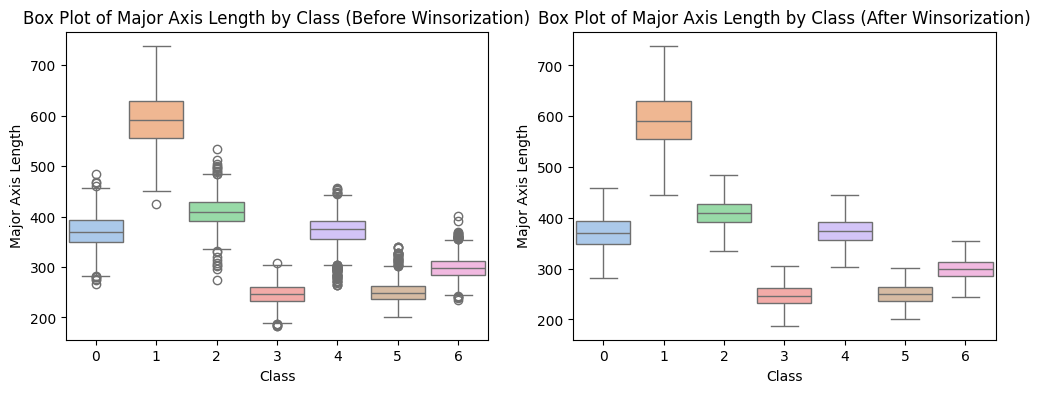

In [60]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.boxplot(x=clean_data['Class_encoded'], y=clean_data['MajorAxisLength'],width=0.9,palette='pastel', ax=ax1)
ax1.set_title('Box Plot of Major Axis Length by Class (Before Winsorization)')
ax1.set_xlabel('Class')
ax1.set_ylabel('Major Axis Length')

sns.boxplot(x=clean_winsorized['Class_encoded'], y=clean_winsorized['MajorAxisLength'],width=0.9,palette='pastel', ax=ax2)
ax2.set_title('Box Plot of Major Axis Length by Class (After Winsorization)')
ax2.set_xlabel('Class')
ax2.set_ylabel('Major Axis Length')
plt.show()

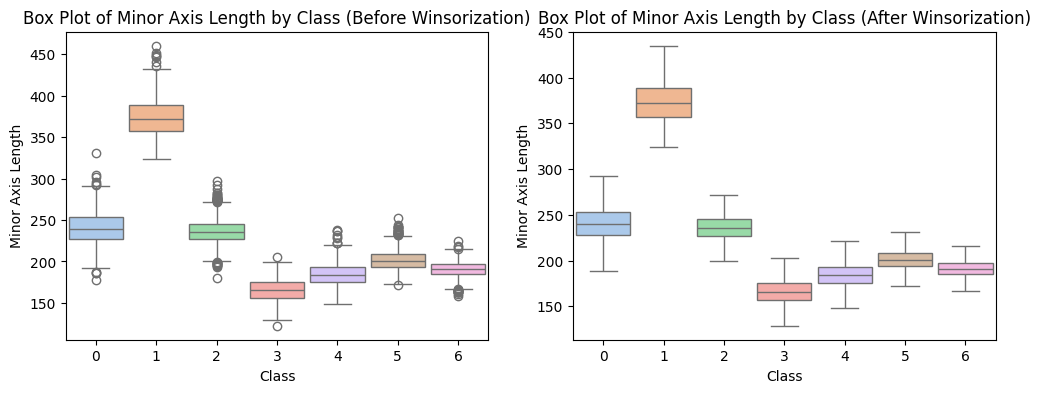

In [61]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.boxplot(x=clean_data['Class_encoded'], y=clean_data['MinorAxisLength'],width=0.9,palette='pastel', ax=ax1)
ax1.set_title('Box Plot of Minor Axis Length by Class (Before Winsorization)')
ax1.set_xlabel('Class')
ax1.set_ylabel('Minor Axis Length')

sns.boxplot(x=clean_winsorized['Class_encoded'], y=clean_winsorized['MinorAxisLength'],width=0.9,palette='pastel', ax=ax2)
ax2.set_title('Box Plot of Minor Axis Length by Class (After Winsorization)')
ax2.set_xlabel('Class')
ax2.set_ylabel('Minor Axis Length')
plt.show()

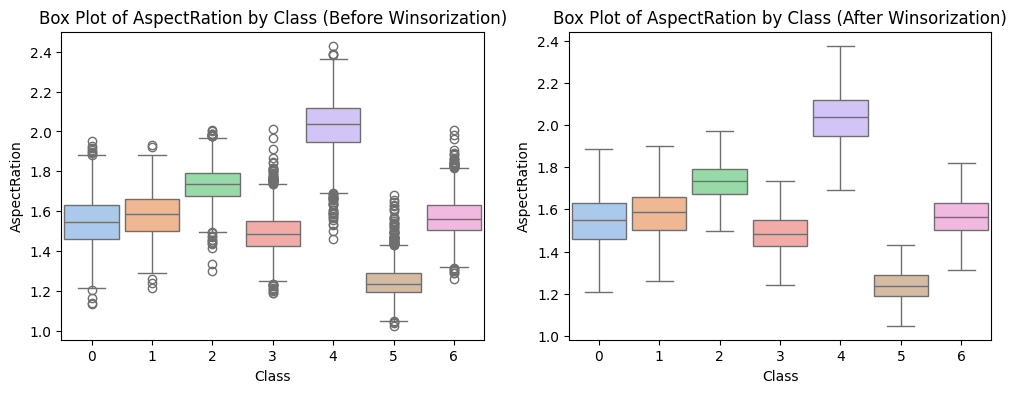

In [62]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.boxplot(x=clean_data['Class_encoded'], y=clean_data['AspectRation'],width=0.9,palette='pastel', ax=ax1)
ax1.set_title('Box Plot of AspectRation by Class (Before Winsorization)')
ax1.set_xlabel('Class')
ax1.set_ylabel('AspectRation')

sns.boxplot(x=clean_winsorized['Class_encoded'], y=clean_winsorized['AspectRation'],width=0.9,palette='pastel', ax=ax2)
ax2.set_title('Box Plot of AspectRation by Class (After Winsorization)')
ax2.set_xlabel('Class')
ax2.set_ylabel('AspectRation')
plt.show()

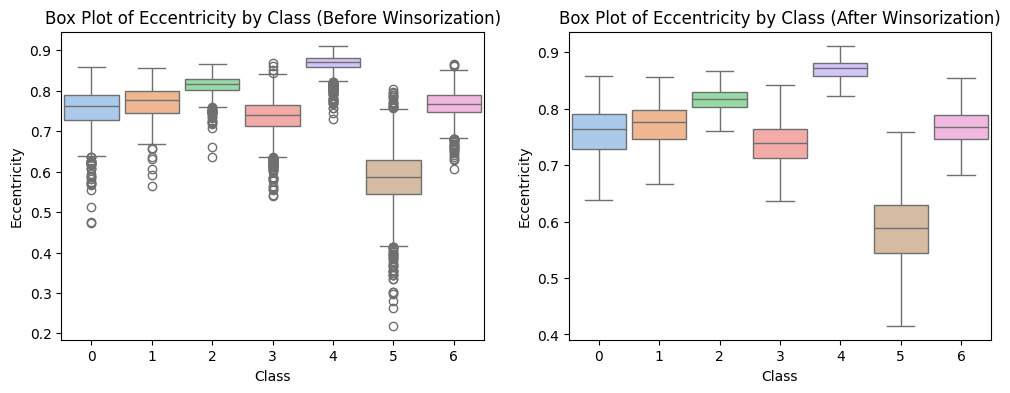

In [63]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.boxplot(x=clean_data['Class_encoded'], y=clean_data['Eccentricity'],width=0.9,palette='pastel', ax=ax1)
ax1.set_title('Box Plot of Eccentricity by Class (Before Winsorization)')
ax1.set_xlabel('Class')
ax1.set_ylabel('Eccentricity')

sns.boxplot(x=clean_winsorized['Class_encoded'], y=clean_winsorized['Eccentricity'],width=0.9,palette='pastel', ax=ax2)
ax2.set_title('Box Plot of Eccentricity by Class (After Winsorization)')
ax2.set_xlabel('Class')
ax2.set_ylabel('Eccentricity')
plt.show()

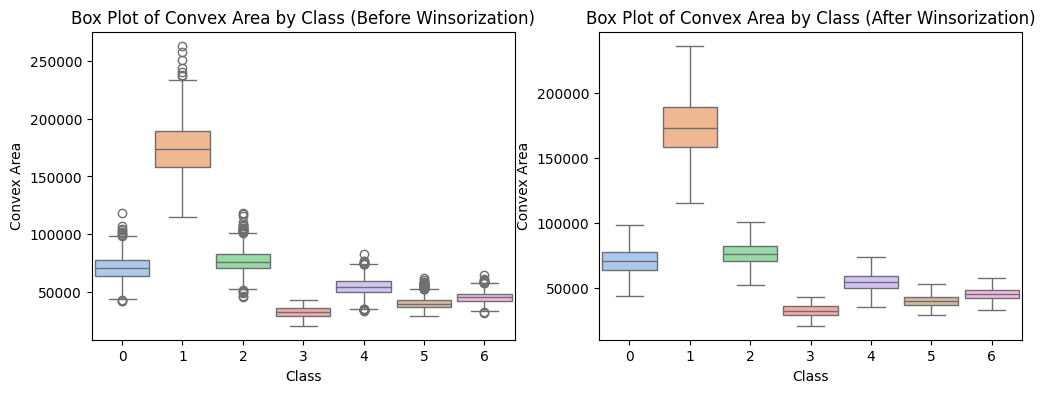

In [64]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.boxplot(x=clean_data['Class_encoded'], y=clean_data['ConvexArea'],width=0.9,palette='pastel', ax=ax1)
ax1.set_title('Box Plot of Convex Area by Class (Before Winsorization)')
ax1.set_xlabel('Class')
ax1.set_ylabel('Convex Area')

sns.boxplot(x=clean_winsorized['Class_encoded'], y=clean_winsorized['ConvexArea'],width=0.9,palette='pastel', ax=ax2)
ax2.set_title('Box Plot of Convex Area by Class (After Winsorization)')
ax2.set_xlabel('Class')
ax2.set_ylabel('Convex Area')
plt.show()

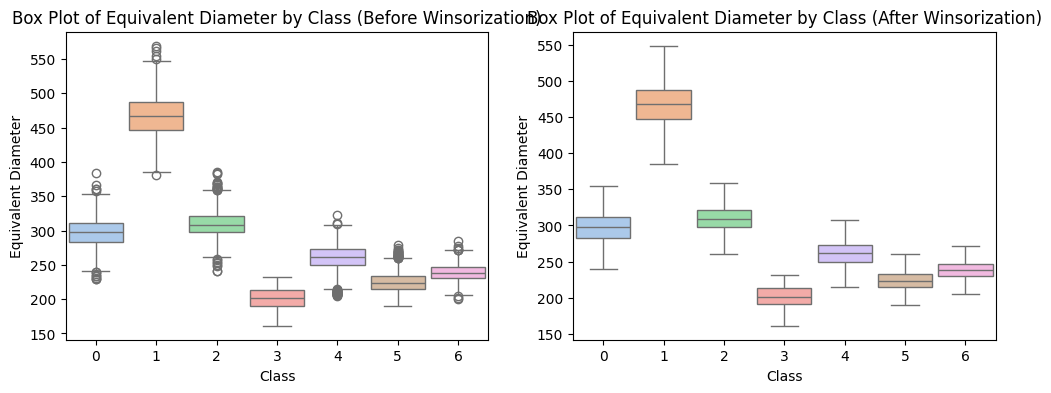

In [65]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.boxplot(x=clean_data['Class_encoded'], y=clean_data['EquivDiameter'],width=0.9,palette='pastel', ax=ax1)
ax1.set_title('Box Plot of Equivalent Diameter by Class (Before Winsorization)')
ax1.set_xlabel('Class')
ax1.set_ylabel('Equivalent Diameter')

sns.boxplot(x=clean_winsorized['Class_encoded'], y=clean_winsorized['EquivDiameter'],width=0.9,palette='pastel', ax=ax2)
ax2.set_title('Box Plot of Equivalent Diameter by Class (After Winsorization)')
ax2.set_xlabel('Class')
ax2.set_ylabel('Equivalent Diameter')
plt.show()

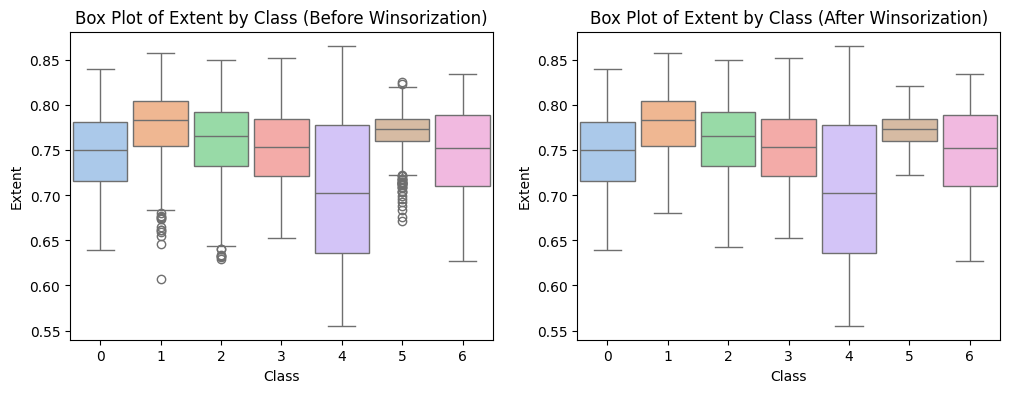

In [66]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.boxplot(x=clean_data['Class_encoded'], y=clean_data['Extent'],width=0.9,palette='pastel', ax=ax1)
ax1.set_title('Box Plot of Extent by Class (Before Winsorization)')
ax1.set_xlabel('Class')
ax1.set_ylabel('Extent')

sns.boxplot(x=clean_winsorized['Class_encoded'], y=clean_winsorized['Extent'],width=0.9,palette='pastel', ax=ax2)
ax2.set_title('Box Plot of Extent by Class (After Winsorization)')
ax2.set_xlabel('Class')
ax2.set_ylabel('Extent')
plt.show()

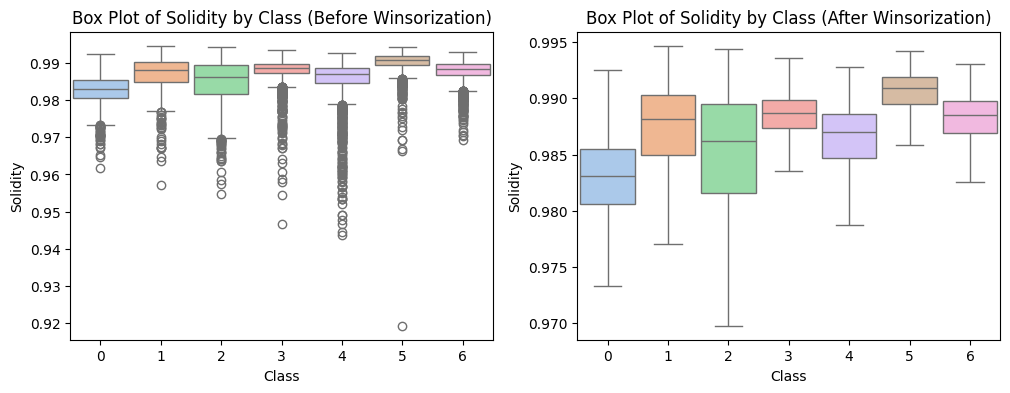

In [67]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.boxplot(x=clean_data['Class_encoded'], y=clean_data['Solidity'],width=0.9,palette='pastel', ax=ax1)
ax1.set_title('Box Plot of Solidity by Class (Before Winsorization)')
ax1.set_xlabel('Class')
ax1.set_ylabel('Solidity')

sns.boxplot(x=clean_winsorized['Class_encoded'], y=clean_winsorized['Solidity'],width=0.9,palette='pastel', ax=ax2)
ax2.set_title('Box Plot of Solidity by Class (After Winsorization)')
ax2.set_xlabel('Class')
ax2.set_ylabel('Solidity')
plt.show()

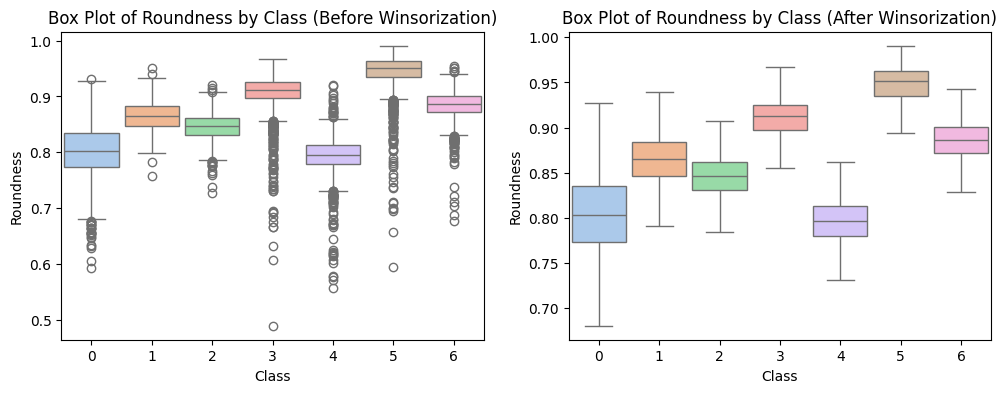

In [68]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.boxplot(x=clean_data['Class_encoded'], y=clean_data['roundness'],width=0.9,palette='pastel', ax=ax1)
ax1.set_title('Box Plot of Roundness by Class (Before Winsorization)')
ax1.set_xlabel('Class')
ax1.set_ylabel('Roundness')

sns.boxplot(x=clean_winsorized['Class_encoded'], y=clean_winsorized['roundness'],width=0.9,palette='pastel', ax=ax2)
ax2.set_title('Box Plot of Roundness by Class (After Winsorization)')
ax2.set_xlabel('Class')
ax2.set_ylabel('Roundness')
plt.show()

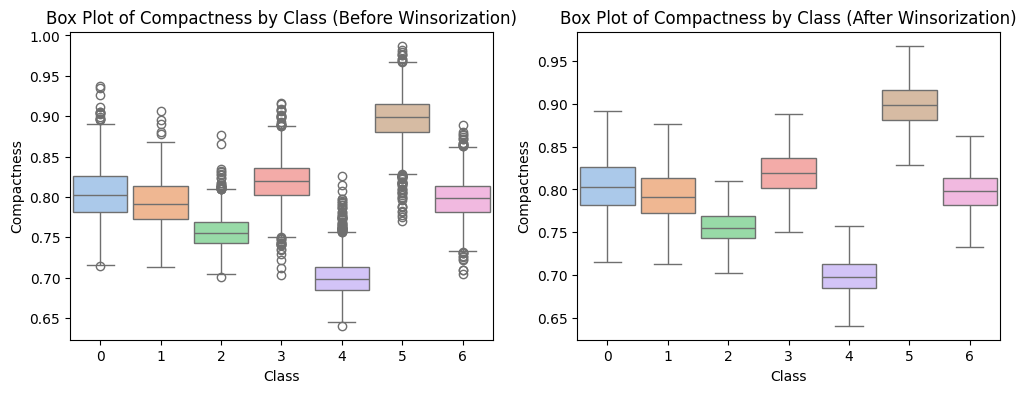

In [69]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.boxplot(x=clean_data['Class_encoded'], y=clean_data['Compactness'],width=0.9,palette='pastel', ax=ax1)
ax1.set_title('Box Plot of Compactness by Class (Before Winsorization)')
ax1.set_xlabel('Class')
ax1.set_ylabel('Compactness')

sns.boxplot(x=clean_winsorized['Class_encoded'], y=clean_winsorized['Compactness'],width=0.9,palette='pastel', ax=ax2)
ax2.set_title('Box Plot of Compactness by Class (After Winsorization)')
ax2.set_xlabel('Class')
ax2.set_ylabel('Compactness')
plt.show()

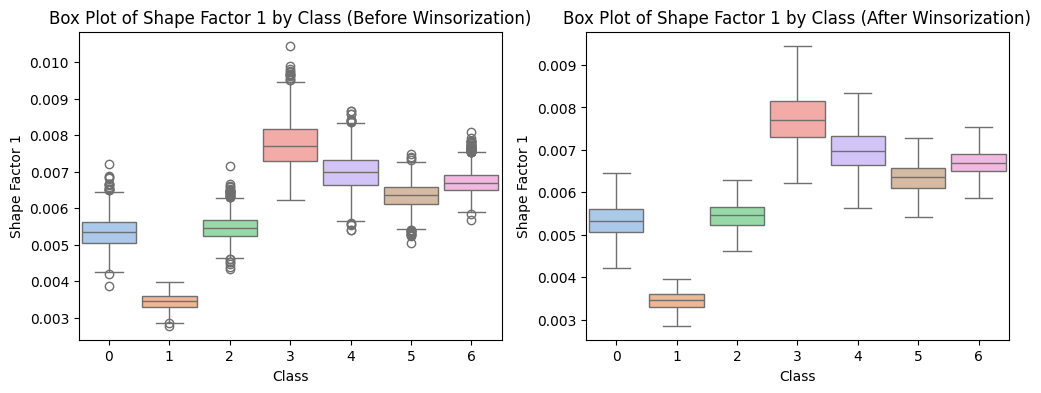

In [70]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.boxplot(x=clean_data['Class_encoded'], y=clean_data['ShapeFactor1'],width=0.9,palette='pastel', ax=ax1)
ax1.set_title('Box Plot of Shape Factor 1 by Class (Before Winsorization)')
ax1.set_xlabel('Class')
ax1.set_ylabel('Shape Factor 1')

sns.boxplot(x=clean_winsorized['Class_encoded'], y=clean_winsorized['ShapeFactor1'],width=0.9,palette='pastel', ax=ax2)
ax2.set_title('Box Plot of Shape Factor 1 by Class (After Winsorization)')
ax2.set_xlabel('Class')
ax2.set_ylabel('Shape Factor 1')
plt.show()

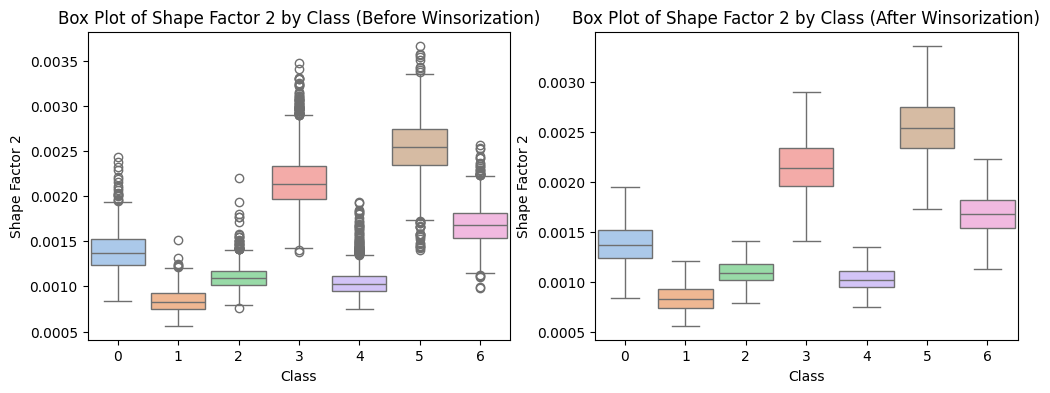

In [71]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.boxplot(x=clean_data['Class_encoded'], y=clean_data['ShapeFactor2'],width=0.9,palette='pastel', ax=ax1)
ax1.set_title('Box Plot of Shape Factor 2 by Class (Before Winsorization)')
ax1.set_xlabel('Class')
ax1.set_ylabel('Shape Factor 2')

sns.boxplot(x=clean_winsorized['Class_encoded'], y=clean_winsorized['ShapeFactor2'],width=0.9,palette='pastel', ax=ax2)
ax2.set_title('Box Plot of Shape Factor 2 by Class (After Winsorization)')
ax2.set_xlabel('Class')
ax2.set_ylabel('Shape Factor 2')
plt.show()

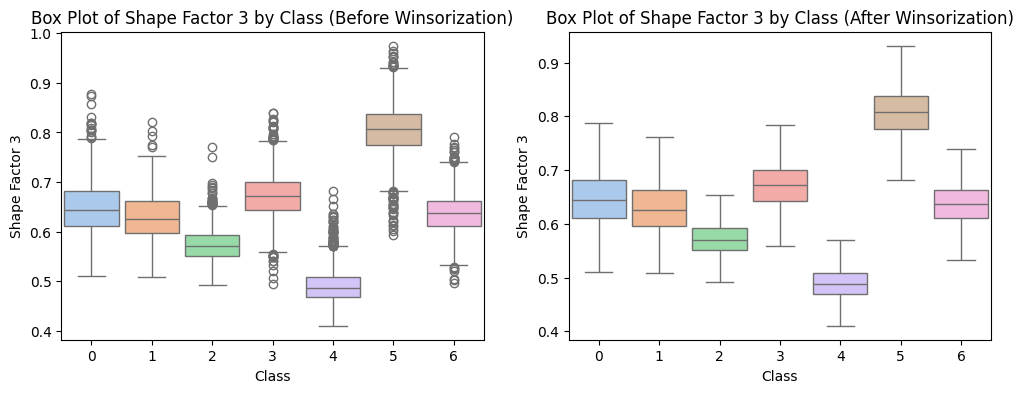

In [72]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.boxplot(x=clean_data['Class_encoded'], y=clean_data['ShapeFactor3'],width=0.9,palette='pastel', ax=ax1)
ax1.set_title('Box Plot of Shape Factor 3 by Class (Before Winsorization)')
ax1.set_xlabel('Class')
ax1.set_ylabel('Shape Factor 3')

sns.boxplot(x=clean_winsorized['Class_encoded'], y=clean_winsorized['ShapeFactor3'],width=0.9,palette='pastel', ax=ax2)
ax2.set_title('Box Plot of Shape Factor 3 by Class (After Winsorization)')
ax2.set_xlabel('Class')
ax2.set_ylabel('Shape Factor 3')
plt.show()

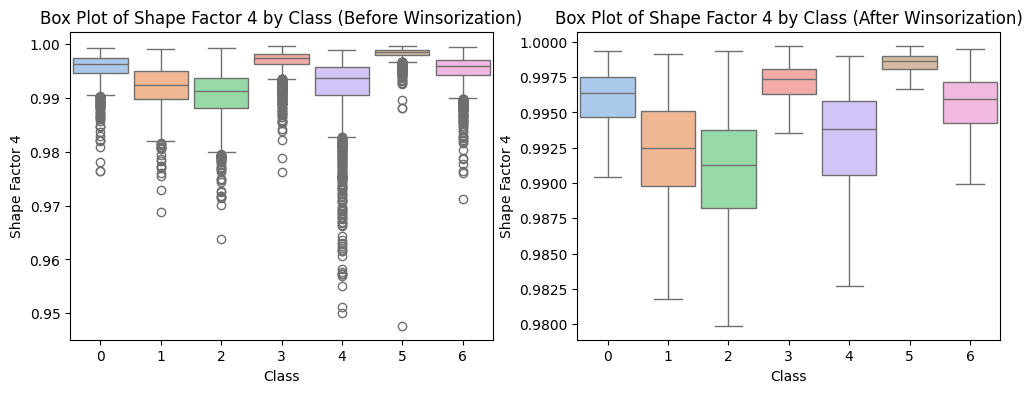

In [73]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.boxplot(x=clean_data['Class_encoded'], y=clean_data['ShapeFactor4'],width=0.9,palette='pastel', ax=ax1)
ax1.set_title('Box Plot of Shape Factor 4 by Class (Before Winsorization)')
ax1.set_xlabel('Class')
ax1.set_ylabel('Shape Factor 4')

sns.boxplot(x=clean_winsorized['Class_encoded'], y=clean_winsorized['ShapeFactor4'],width=0.9,palette='pastel', ax=ax2)
ax2.set_title('Box Plot of Shape Factor 4 by Class (After Winsorization)')
ax2.set_xlabel('Class')
ax2.set_ylabel('Shape Factor 4')
plt.show()

In [74]:
clean_winsorized.drop(columns=['Class'], inplace=True)

<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">2. Logistic Regression Parameters:</h3>


In [75]:
classes = clean_winsorized["Class_encoded"].unique()
classes.sort()
print(f"Unique classes in the dataset: {classes}")

Unique classes in the dataset: [0 1 2 3 4 5 6]


In [76]:
X = clean_winsorized.drop(columns='Class_encoded')
y = clean_winsorized['Class_encoded']

X_main, X_test, y_main, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

validation_ratio = 0.15
remaining_ratio = 1.0 - 0.15
adj_validation_size = validation_ratio / remaining_ratio

X_train, X_val, y_train, y_val = train_test_split(X_main, y_main, test_size=adj_validation_size, random_state=42, stratify=y_main)

print(f"Training set size: {len(X_train)} samples")
print(f"Validation set size: {len(X_val)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 9479 samples
Validation set size: 2032 samples
Test set size: 2032 samples


In [77]:
# Apply SMOTEENN to the training data to address class imbalance by oversampling 
# the minority class and cleaning the data with ENN. This will help improve the 
# performance of our models by providing a more balanced training set and 
# reducing noise from mislabeled or ambiguous samples.
sme = SMOTEENN(random_state=42)

# Fit SMOTEENN on the training data and resample it to create a new training set 
# that is balanced and cleaned. This will generate synthetic samples for the 
# minority class and remove samples that are likely to be noise or misclassified, 
# resulting in a training set that is more suitable for training our machine 
# learning models.
X_train_resampled, y_train_resampled = sme.fit_resample(X_train, y_train)

print(f"Original training set class distribution:\n{y_train.value_counts()}")
print(f"Resampled training set class distribution:\n{pd.Series(y_train_resampled).value_counts()}")


Original training set class distribution:
Class_encoded
3    2482
6    1844
5    1419
4    1302
2    1140
0     926
1     366
Name: count, dtype: int64
Resampled training set class distribution:
Class_encoded
1    2482
3    1687
5    1664
4    1662
2    1582
0    1511
6    1418
Name: count, dtype: int64


In [78]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_val_scaled = scaler.transform(X_val)

<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">3. Building the Logistic Regression Model:</h3>


In [79]:
log_reg_model = LogisticRegression(random_state=42, max_iter=1000)
log_reg_model.fit(X_train_scaled, y_train_resampled)
log_reg_model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">4. Model Evaluation:</h3>


In [80]:
distinct_pairs

,Class,Class_encoded
0,SEKER,5
1,BARBUNYA,0
2,BOMBAY,1
3,CALI,2
4,HOROZ,4
5,SIRA,6
6,DERMASON,3


In [81]:
y_val_pred = log_reg_model.predict(X_val_scaled)
print("Validation Classification Report for Logistic Regression:")
print(classification_report(y_val, y_val_pred))

Validation Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       198
           1       1.00      1.00      1.00        78
           2       0.91      0.95      0.93       245
           3       0.94      0.91      0.92       532
           4       0.94      0.94      0.94       279
           5       0.96      0.97      0.96       304
           6       0.86      0.90      0.88       396

    accuracy                           0.93      2032
   macro avg       0.94      0.94      0.94      2032
weighted avg       0.93      0.93      0.93      2032



---
<a name = Section1></a>
#### Explanation:

Classification Report (sklearn.metrics.classification_report)

- precision: proportion of predicted positives that are correct = TP / (TP + FP). High = few false positives.
- recall (sensitivity): proportion of actual positives found = TP / (TP + FN). High = few false negatives.
- f1-score: harmonic mean of precision and recall = 2 * (precision * recall)/(precision + recall). Balances precision vs recall.
- support: number of true instances for the class in the test set (counts used to weight averages).
- accuracy (row): overall fraction correct = (sum TP) / (total samples). Not informative for imbalanced data alone.
- macro avg: unweighted mean of per-class metrics (treats all classes equally), ignores class frequency.
- weighted avg: mean of per-class metrics weighted by support (reflects class imbalance).

---
<a name = Section2></a>
#### Insights:

- For class 0 (BARBUNYA) : Precision is 0.94, Reccall is 0.90, F1-score is 0.92 and Support is 198. It means proper Class Detection is very high and only in few cases it has failed to detect the class.
- For class 1 (BOMBAY) : Precision is 1.00, Reccall is 1.00, F1-score is 1.00 and Support is 78. It means it has correctly detected the class every time with no failures.
- For class 2 (CALI) : Precision is 0.91, Reccall is 0.95, F1-score is 0.93 and Support is 245. It means proper Class Detection is very high and only in few cases it has failed to detect the class.
- For class 3 (DERMASON) : Precision is 0.94, Reccall is 0.91, F1-score is 0.92 and Support is 532. It means proper Class Detection is very high and only in few cases it has failed to detect the class.
- For class 4 (HOROZ) : Precision is 0.94, Reccall is 0.94, F1-score is 0.94 and Support is 279. It means proper Class Detection is very high and only in few cases it has failed to detect the class.
- For class 5 (SEKER) : Precision is 0.96, Reccall is 0.97, F1-score is 0.96 and Support is 304. It means proper Class Detection is very high and only in few cases it has failed to detect the class.
- For class 6 (SIRA) : Precision is 0.86, Reccall is 0.90, F1-score is 0.88 and Support is 396. It means proper Class Detection is very high and only in few cases it has failed to detect the class. We can see that, among all the classes max-error has occured in this particular class.

Since our initial dataset was highly imbalanced, for accuracy we can consider the 'weighted avg' in this case which is giving us an overall accuracy of 93%(approx).

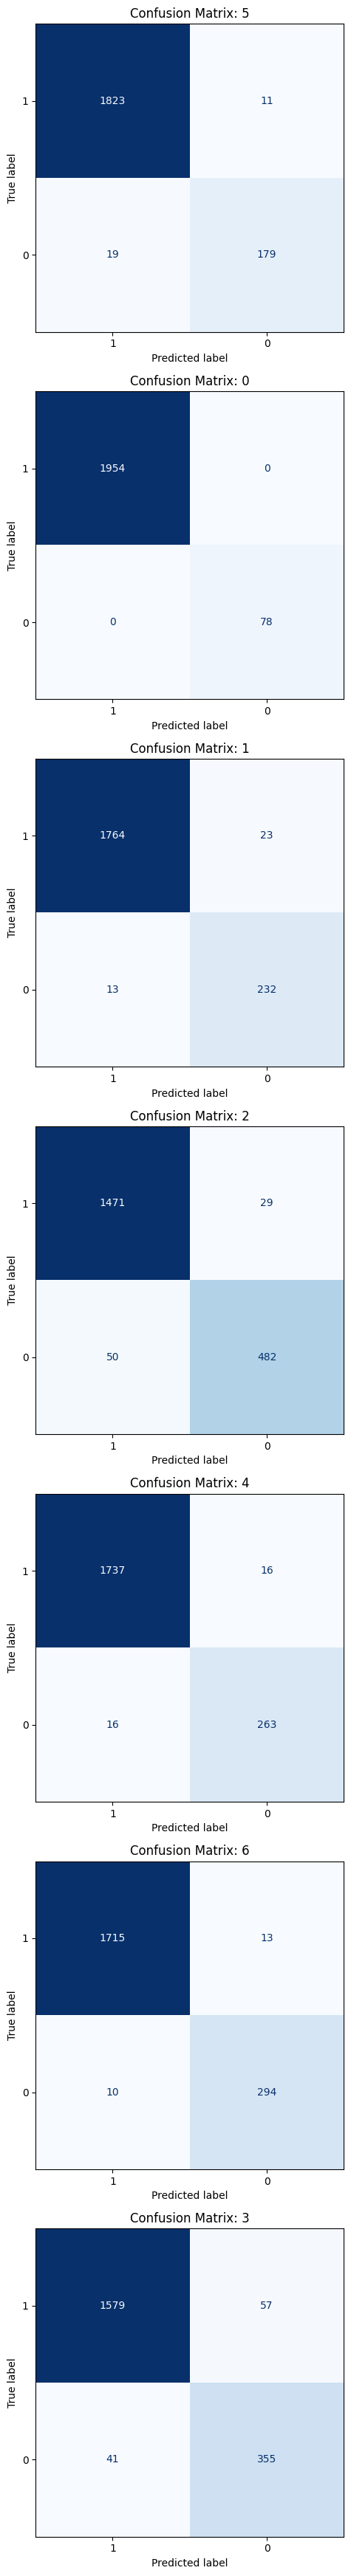

In [82]:
mcm = multilabel_confusion_matrix(y_val, y_val_pred)

target_names = distinct_pairs["Class_encoded"].unique().tolist()

fig, axes = plt.subplots(nrows=len(target_names), ncols=1, figsize=(12, 5 * len(target_names)))

for i, (matrix, label) in enumerate(zip(mcm, distinct_pairs["Class_encoded"])):
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=[1, 0])
    disp.plot(ax=axes[i], cmap=plt.cm.Blues, colorbar=False)
    axes[i].set_title(f"Confusion Matrix: {label}")

plt.tight_layout()
plt.show()

In [83]:
accuracy_score(y_val, y_val_pred)

0.9266732283464567


---
<a name = Section2></a>
#### Insights:

Our Accuracy score for our validation dataset is 92.7%(approx).

<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">5. Hyperparameter Tuning and Optimization:</h3>


In [84]:
# 1. Define the Pipeline
pipeline = Pipeline([
    ('smote_enn', SMOTEENN(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000, solver='saga')) # solver='lbfgs' or 'liblinear' or 'saga' also work for multi-class
])

# 2. Define the Hyperparameter Space
# Use the prefix 'clf__estimator__' to target the Logistic Regression parameters within the pipeline
param_grid = {
    'clf__C': [0.1, 1, 10],            
    'clf__penalty': ['l1', 'l2']       
}

# 3. Initialize the Search
# Use 'f1_samples' or 'f1_macro' for imbalanced multi-label tasks
search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=3, 
    scoring='f1_macro', 
    n_jobs=-1
)

# 4. Fit the Search
search.fit(X_train_scaled, y_train_resampled)

# 5. Access Results
print(f"Best Parameters: {search.best_params_}")
print(f"Best F1 Score: {search.best_score_}")


Best Parameters: {'clf__C': 1, 'clf__penalty': 'l1'}
Best F1 Score: 0.9879372073844469


In [85]:
# 1. Get the best model from the search
best_model = search.best_estimator_
best_model

,steps,"[('smote_enn', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,smote,None
,enn,None
,n_jobs,None
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.92       198
           1       1.00      1.00      1.00        78
           2       0.91      0.95      0.93       245
           3       0.95      0.89      0.92       532
           4       0.94      0.95      0.94       279
           5       0.94      0.97      0.96       304
           6       0.85      0.90      0.87       396

    accuracy                           0.92      2032
   macro avg       0.93      0.94      0.93      2032
weighted avg       0.92      0.92      0.92      2032



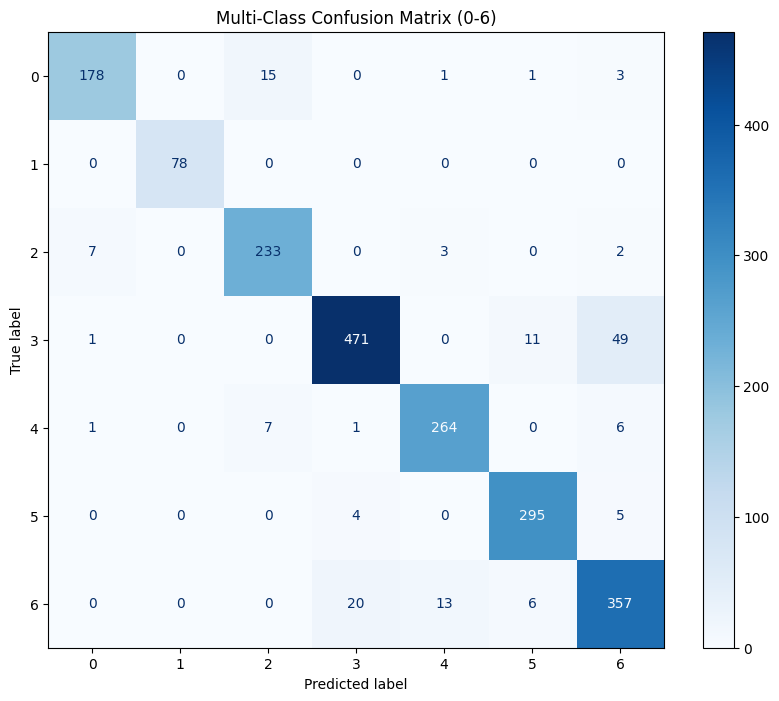

In [86]:
# 2. Predict on the validation set
y_pred = best_model.predict(X_val_scaled) 

# 3. Print the classification report
# This will show Precision, Recall, and F1 for each of our 7 classes
print("Classification Report:")
print(classification_report(y_val, y_pred))

# 4. Plot the Multi-class Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay.from_predictions(
    y_val, 
    y_pred, 
    display_labels=[0, 1, 2, 3, 4, 5, 6], # or our actual class names
    cmap=plt.cm.Blues,
    ax=ax
)
plt.title("Multi-Class Confusion Matrix (0-6)")
plt.show()

In [87]:
accuracy_score(y_val, y_pred)

0.9232283464566929


---
<a name = Section2></a>
#### Insights:

After hyperparameter spacing, our Accuracy score is 92.32%(approx) on the validation dataset.

In [88]:
X_test_scaled = scaler.transform(X_test)
y_hat = best_model.predict(X_test_scaled) 

accuracy_score(y_test, y_hat)

0.9178149606299213


---
<a name = Section2></a>
#### Insights:

After hyperparameter spacing, our Accuracy score is 91.78%(approx) on the test dataset.

In [89]:
# 1. Define a Stratified split 
# 'Stratified' ensures each fold has the same ratio of classes (0-6)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Run cross-validation on your Pipeline
# We use the pipeline so SMOTE-ENN is applied ONLY to training folds
cv_scores = cross_val_score(
    pipeline,           # Your SMOTE-ENN + Logistic Regression pipe
    X_train_scaled,     # Features
    y_train_resampled,  # Labels (0-6)
    cv=skf,             # 5-fold stratified CV
    scoring='f1_macro', # Metric for imbalanced multi-class
    n_jobs=-1
)

# 3. View results
print(f"F1-Scores for each fold: {cv_scores}")
print(f"Mean F1-Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

F1-Scores for each fold: [0.98617281 0.98799615 0.9880865  0.98806834 0.98983418]
Mean F1-Score: 0.9880
Standard Deviation: 0.0012


In [90]:
cv_scores_val = cross_val_score(
    pipeline,           # Your SMOTE-ENN + Logistic Regression pipe
    X_val_scaled,     # Features
    y_val,  # Labels (0-6)
    cv=skf,             # 5-fold stratified CV
    scoring='f1_macro', # Metric for imbalanced multi-class
    n_jobs=-1
)

print(f"F1-Scores for each fold: {cv_scores_val}")
print(f"Mean F1-Score: {cv_scores_val.mean():.4f}")
print(f"Standard Deviation: {cv_scores_val.std():.4f}")

F1-Scores for each fold: [0.94656651 0.94292794 0.92125856 0.91684296 0.91865684]
Mean F1-Score: 0.9293
Standard Deviation: 0.0128


In [91]:
cv_scores_test = cross_val_score(
    pipeline,           # Your SMOTE-ENN + Logistic Regression pipe
    X_test_scaled,     # Features
    y_test,  # Labels (0-6)
    cv=skf,             # 5-fold stratified CV
    scoring='f1_macro', # Metric for imbalanced multi-class
    n_jobs=-1
)

print(f"F1-Scores for each fold: {cv_scores_test}")
print(f"Mean F1-Score: {cv_scores_test.mean():.4f}")
print(f"Standard Deviation: {cv_scores_test.std():.4f}")

F1-Scores for each fold: [0.93207294 0.93424178 0.9437122  0.93290152 0.92700877]
Mean F1-Score: 0.9340
Standard Deviation: 0.0054


---
<a name = Section2></a>
#### Insights:

- The above F1-score tells us that irrespective of the fact whether it is train data or validation data or test data our model can predict more than 90% of the time accurately, our model hits the absolute center of the correct target. It almost never misses, and it almost never gets the targets confused with one another.
- There is a small drop from 98% (Train) to 93% (Test). This is a tiny bit of "overfitting" (where the model memorized some noise in the training data), but it is very common when using SMOTE-ENN because the synthetic data makes the training set "easier" to learn than the real-world test data.
- The fact that your Validation (92.9%) and Test (93.4%) scores are almost identical is the "Gold Standard." It means your model is stable and generalizes perfectly to completely unseen data.